# Project Preprocessing: Expert Discovery System and Collaboration Network Analysis with HORUS data

# 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from spellchecker import SpellChecker
from tqdm import tqdm
from IPython.display import display

import os
from pathlib import Path

# NLP - Classical pipeline
import ftfy
from gensim.models.phrases import Phrases, Phraser
import nltk
from nltk.corpus import stopwords

# Language detection
from lingua import Language, LanguageDetectorBuilder

# spaCy (multilingual lemmatization)
import spacy

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All imports successful.")

[nltk_data] Downloading package punkt to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/fvalderramab/nltk_data...


All imports successful.


[nltk_data]   Package omw-1.4 is already up-to-date!


### 1.1. Environment Configuration (Mounting Drive)

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data/")
else:
    base_path = Path("../data/")

### 1.2. Faculty-Level Data Loading

Load faculty-specific datasets and assign the faculty label explicitly.

In [3]:
products_engineering = pd.read_excel(base_path / "raw/productos_ingenieria.xlsx").assign(faculty='Ingeniería')
products_arts = pd.read_excel(base_path / "raw/productos_artes.xlsx").assign(faculty='Artes')
products_agricultural_sciences = pd.read_excel(base_path / "raw/productos_ciencias_agrarias.xlsx").assign(faculty='Ciencias Agrarias')
products_economic_sciences = pd.read_excel(base_path / "raw/productos_ciencias_economicas.xlsx").assign(faculty='Ciencias Económicas')
products_human_sciences = pd.read_excel(base_path / "raw/productos_ciencias_humanas.xlsx").assign(faculty='Ciencias Humanas')
products_sciences = pd.read_excel(base_path / "raw/productos_ciencias.xlsx").assign(faculty='Ciencias')
products_law = pd.read_excel(base_path / "raw/productos_derecho.xlsx").assign(faculty='Derecho')
products_nursing = pd.read_excel(base_path / "raw/productos_enfermeria.xlsx").assign(faculty='Enfermería')
products_medicine = pd.read_excel(base_path / "raw/productos_medicina.xlsx").assign(faculty='Medicina')
products_dentistry = pd.read_excel(base_path / "raw/productos_odontologia.xlsx").assign(faculty='Odontología')
products_veterinary = pd.read_excel(base_path / "raw/productos_veterinaria.xlsx").assign(faculty='Veterinaria')

products_bogota = pd.concat([
    products_engineering,
    products_arts,
    products_agricultural_sciences,
    products_economic_sciences,
    products_human_sciences,
    products_sciences,
    products_law,
    products_nursing,
    products_medicine,
    products_dentistry,
    products_veterinary
], ignore_index=True)

column_mapping = {
    'Título original': 'original_title',
    'Descripción original': 'original_description',
    'Revista / Conferencia': 'journal_conference',
    'Coautores': 'coauthors',
    'Doi': 'doi',
    'ISBN': 'isbn',
    'ISSN': 'issn',
    'Citaciones': 'citations',
    'Idioma': 'language',
    'Fecha': 'date',
    'Tipo': 'type',
    'Fuente': 'source',
    'Enlace': 'link',
    'faculty': 'faculty'
}
products_bogota.rename(columns=column_mapping, inplace=True)

research_professors = pd.read_csv(base_path / 'external/docentes_investigadores.csv')
column_mapping_2 = {
    'Nombre': 'name',
    'Vinculación': 'affiliation',
    'Cantidad de productos': 'product_count'
}
research_professors.rename(columns=column_mapping_2, inplace=True)
active_research_professors = research_professors[research_professors['affiliation'] == 'Activo'].reset_index(drop=True)

### 1.3. Useful functions

In [4]:
STATIC_NULL_CONVENTIONS = {
    # Generic nulls
    'no reportado', 'no disponible', 'sin información', 'sin informacion',
    'n/a', 'na', 'none', 'nd', 'n.d.', 'n.a.', 's.r.', 'nr', 'nan',
    # Punctuation-only
    '-', '--', '---', '----------', '.', '..', '...', '_', '__',
    # Single characters / trivial
    'a', 'x', 'xx', 'xxx', 'xxxx', '1', '0',
    # Spanish document references (useless for NLP)
    'ver documento completo en pdf',
    'ver documento completo',
    'ver pdf',
    'documento adjunto',
    'véase documento',
    'desconocido',
    
    # Context-specific duplicated null conventions
    'ver formato para la inclusión de información complementaria del proyecto de investigación',
    'esta información no está disponible.',
    'esta información no está disponible',
    'para ver la editorial completa, favor descargar el pdf.',
    'para ver la editorial completa, favor descargar el pdf',
    
    # Empty string
    '',
}

# Regex-based check for additional patterns (repeated chars, only symbols)
CONVENTION_PATTERNS = [
    r'^\s*[-_=*#.]{2,}\s*$',      # e.g. '-----', '======'
    r'^\s*[a-zA-Z0-9]\s*$',       # single character
    r'^\s*\d{1,2}\s*$',           # 1 or 2 digit numbers
    r'^ver\s+documento',           # "ver documento completo en PDF" variants
    r'^n\.?\s*[ad]\.?\s*$',        # N.A., N.D., etc.
    r'^s\.?\s*r\.?\s*$',           # S.R.
    r'^\W+$',                      # only non-word characters
]

def normalize_for_match(name):
    name = str(name).lower().strip()
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                   if unicodedata.category(c) != 'Mn')
    name = re.sub(r'[.,]', '', name)
    return ' '.join(name.split())

def extract_coauthors(text):
    if pd.isna(text):
        return []
    return [n.strip() for n in str(text).split(',') if n.strip()]

def has_active_professor(coauthors_str, professors_set):
    names = extract_coauthors(coauthors_str)
    return any(normalize_for_match(n) in professors_set for n in names)

def is_active_professor(name, professors_set):
    return normalize_for_match(name) in professors_set

def count_coauthors(text):
    if pd.isna(text) or str(text).strip() == '':
        return 0
    return len([x for x in str(text).split(',') if x.strip()])

def load_processed_data_parquet():
    parquet_path = (output_path if 'output_path' in globals() else base_path / "processed") / "processed_products.parquet"
    products_bogota = pd.read_parquet(parquet_path, engine="pyarrow")

    print(f"Loaded: {parquet_path}")
    print(f"Shape: {products_bogota.shape}")
    return products_bogota

### 1.4. Filter to active professors only

In [5]:
active_professors_names = set(
    active_research_professors['name'].dropna().apply(normalize_for_match)
)
active_mask = products_bogota['coauthors'].apply(
    lambda x: has_active_professor(x, active_professors_names)
)
products_bogota = products_bogota[active_mask].copy().reset_index(drop=True)
print(f"Records with at least one active professor: {len(products_bogota)}")
print(f"Records excluded: {len(active_mask) - active_mask.sum()}")

Records with at least one active professor: 109836
Records excluded: 43488


# 2. Preprocessing phase

## 2.1. Shared Preprocessing (Preprocessing for embeddings)

**Purpose:** Cleans text by maintaining maximum syntactic preservation for cross-lingual Transformers.

**Insight:** Avoids strict lemmatization or stopword removal as embeddings and LLMs benefit from natural sentence structure.

### 2.1.1. Basic Text Normalization & Noise Removal

**Purpose:** Sequentially applies Mojibake repair (`ftfy`), HTML/LaTeX tag removal, and Unicode uniformization.

#### 2.1.1.1. Corrupt character repair (Mojibake)

Fixes bytes decoded with the wrong codec (e.g. UTF-8 read as latin-1).
Must run first because it operates on raw byte-level corruption patterns.
Different from Unicode normalization in 2.1.1.3, which handles valid but
inconsistent Unicode characters (curly quotes, special dashes, etc.).

In [6]:
print("=" * 60)
print("CORRUPT CHARACTER REPAIR")
print("=" * 60)

# Common mojibake patterns in Spanish academic texts
MOJIBAKE_MAP = {
    'Ã¡': 'á', 'Ã©': 'é', 'Ã­': 'í', 'Ã³': 'ó', 'Ãº': 'ú',
    'Ã ': 'à', 'Ã¨': 'è', 'Ã¬': 'ì', 'Ã²': 'ò', 'Ã¹': 'ù',
    'Ã\x81': 'Á', 'Ã\x89': 'É', 'Ã\x8d': 'Í', 'Ã\x93': 'Ó', 'Ã\x9a': 'Ú',
    'Ã±': 'ñ', 'Ã\x91': 'Ñ',
    'Ã¼': 'ü', 'Ã\x9c': 'Ü',
    'â€œ': '"', 'â€': '"', 'â€™': "'", 'â€˜': "'",
    'â€"': '–', 'â€"': '—',
    'Â°': '°', 'Â©': '©', 'Â®': '®',
    '\x00': '',   # null bytes
    # '\ufffd': '', # replacement character �
}

def fix_mojibake(text):
    """Attempt to fix common encoding corruption patterns."""
    if pd.isna(text):
        return text
    text = str(text)
    for corrupt, correct in MOJIBAKE_MAP.items():
        text = text.replace(corrupt, correct)
    # Try ftfy as a fallback if available
    try:
        text = ftfy.fix_text(text)
    except ImportError:
        pass
    return text


# --- Capture before state for comparison ---
title_before = products_bogota['original_title'].copy()
desc_before = products_bogota['original_description'].copy()

# --- Apply repair ---
for col in ['original_title', 'original_description']:
    products_bogota[col] = products_bogota[col].apply(fix_mojibake)

# --- Identify changed rows ---
title_changed = title_before.fillna('') != products_bogota['original_title'].fillna('')
desc_changed = desc_before.fillna('') != products_bogota['original_description'].fillna('')
any_change = title_changed | desc_changed

print(f"Titles repaired:       {title_changed.sum()}")
print(f"Descriptions repaired: {desc_changed.sum()}")
print(f"Any field repaired:    {any_change.sum()}")

if any_change.sum() > 0:
    comparison = []
    for idx in products_bogota[any_change].index:
        comparison.append({
            'Title BEFORE':        str(title_before.at[idx]),
            'Title AFTER':         str(products_bogota.at[idx, 'original_title']),
            'Title changed':       title_changed[idx],
            'Desc BEFORE (120c)':  str(desc_before.at[idx])[:500],
            'Desc AFTER (120c)':   str(products_bogota.at[idx, 'original_description'])[:500],
            'Desc changed':        desc_changed[idx],
        })
    df_comparison = pd.DataFrame(comparison)
    display(df_comparison[df_comparison[['Title changed', 'Desc changed']].any(axis=1)].head(50))
else:
    print("\nNo mojibake detected. Checking high-density non-ASCII characters:")
    unicode_density = products_bogota['original_title'].fillna('').apply(
        lambda t: sum(1 for c in t if ord(c) > 127) / max(len(t), 1)
    )
    suspects = unicode_density[unicode_density > 0.15].index
    print(f"High-unicode-density titles found: {len(suspects)}")
    if len(suspects):
        display(products_bogota.loc[suspects,
                ['original_title', 'original_description', 'faculty']].head(10))

del title_before, desc_before, title_changed, desc_changed, any_change

CORRUPT CHARACTER REPAIR
Titles repaired:       1109
Descriptions repaired: 6366
Any field repaired:    6996


,Title BEFORE,Title AFTER,Title changed,Desc BEFORE (120c),Desc AFTER (120c),Desc changed
0,Recent advances in solvent development for car...,Recent advances in solvent development for car...,False,"The practices of carbon capture, storage, and ...","The practices of carbon capture, storage, and ...",True
1,Computational Model of Bone Remodeling Integra...,Computational Model of Bone Remodeling Integra...,False,Bone remodeling is a fundamental physiological...,Bone remodeling is a fundamental physiological...,True
2,Kernel density matrices for probabilistic deep...,Kernel density matrices for probabilistic deep...,False,This paper introduces a novel approach to prob...,This paper introduces a novel approach to prob...,True
3,"Functional Data Analysis for the Structural, C...","Functional Data Analysis for the Structural, C...",False,Additive manufacturing via selective laser sin...,Additive manufacturing via selective laser sin...,True
4,Mechanical Behavior of Paving Stones Made from...,Mechanical Behavior of Paving Stones Made from...,False,This study investigates the mechanical perform...,This study investigates the mechanical perform...,True
5,Corrosion Performance of (TiAlZrTaNb)Nx High-E...,Corrosion Performance of (TiAlZrTaNb)Nx High-E...,False,"In this study, the electrochemical corrosion b...","In this study, the electrochemical corrosion b...",True
6,Inteligencia artificial en la educación en ing...,Inteligencia artificial en la educación en ing...,False,La irrupción de la inteligencia artificial (IA...,La irrupción de la inteligencia artificial (IA...,True
7,M-Learning: Heuristic Approach for Delayed Rew...,M-Learning: Heuristic Approach for Delayed Rew...,False,The current design of reinforcement learning m...,The current design of reinforcement learning m...,True
8,Fly Ash Blended Cement Resistivity Monitoring ...,Fly Ash Blended Cement Resistivity Monitoring ...,False,"In this paper, electrical resistivity monitori...","In this paper, electrical resistivity monitori...",True
9,Estudio de caso para la optimización del esque...,Estudio de caso para la optimización del esque...,False,Este documento presenta el estudio de caso par...,Este documento presenta el estudio de caso par...,True


In [7]:
print("=" * 60)
print("1.1.b. AUTOMATIC REPAIR FOR LOST CHARACTERS")
print("=" * 60)

# 1. Initialize Spanish spell checker
spell = SpellChecker(language='es')

# Optional: add academic/technical vocabulary to avoid wrong corrections
spell.word_frequency.load_words(['infraestructuras', 'ecosistemas', 'heterogéneas', 'espaciales', 'distribuido'])

# 2. Characters commonly lost in Spanish text
MISSING_CHARS = ['á', 'é', 'í', 'ó', 'ú', 'ñ', 'Á', 'É', 'Í', 'Ó', 'Ú', 'Ñ', 'ü']

# Ultra-fast cache for corrections
correction_cache = {}

def repair_word_with_wildcard(broken_word):
    """
    Repair the replacement-character \ufffd by preserving casing (ALL CAPS,
    Title case or lowercase) and using a cache for speed.
    """
    if broken_word in correction_cache:
        return correction_cache[broken_word]
    
    # 1. Clean and detect style
    letters_only = broken_word.replace('\ufffd', '')
    if not letters_only:
        return broken_word

    is_all_upper = letters_only.isupper()
    is_title_like = broken_word[0].isupper()

    # 2. Try direct replacements using the known characters list
    for ch in MISSING_CHARS:
        # Adjust character to match original word style
        if is_all_upper:
            adjusted = ch.upper()
        elif is_title_like and broken_word.startswith('\ufffd'):
            adjusted = ch.upper()
        else:
            adjusted = ch.lower()
            
        candidate = broken_word.replace('\ufffd', adjusted)
        
        # If the candidate exists in the spell vocabulary (case-insensitive)
        if candidate.lower() in spell:
            correction_cache[broken_word] = candidate
            return candidate
            
    # 3. FALLBACK: let the spellchecker propose a correction,
    # then reapply the original casing style
    correction = spell.correction(letters_only)
    
    if correction:
        if is_all_upper:
            result = correction.upper()
        elif is_title_like:
            result = correction.capitalize()
        else:
            result = correction.lower()
        
        correction_cache[broken_word] = result
        return result
        
    # 4. If nothing worked, return the letters we have (without the replacement char)
    correction_cache[broken_word] = letters_only
    return letters_only

def smart_repair_text(text):
    """Apply repairs only to texts that contain the replacement character \ufffd."""
    if pd.isna(text) or '\ufffd' not in str(text):
        return text
    
    text = str(text)
    # Extract words that contain the replacement character
    broken_words = set(re.findall(r'[a-zA-ZáéíóúñÁÉÍÓÚÑ]*\ufffd[a-zA-ZáéíóúñÁÉÍÓÚÑ\ufffd]*', text))
    
    for bw in broken_words:
        fixed = repair_word_with_wildcard(bw)
        text = text.replace(bw, fixed)
        
    return text

# 3. Apply to columns
for col in ['original_title', 'original_description']:
    before = products_bogota[col].copy()
    
    # Fast path: most rows won't contain '\ufffd' so the function is cheap
    products_bogota[col] = products_bogota[col].apply(smart_repair_text)
    
    changed = (before != products_bogota[col]).sum()
    print(f"  '{col}': {changed} records repaired with spell-based fixer.")

1.1.b. AUTOMATIC REPAIR FOR LOST CHARACTERS
  'original_title': 20 records repaired with spell-based fixer.
  'original_description': 39951 records repaired with spell-based fixer.


#### 2.1.1.2. Noise and Boilerplate Cleaning

In [8]:
print("=" * 60)
print("NOISE AND BOILERPLATE CLEANING")
print("=" * 60)

# --- Patterns considered boilerplate / noise in academic abstracts ---
BOILERPLATE_PATTERNS = [
    # Publisher & rights boilerplate
    r'all rights reserved\.?',
    r'copyright\s*©?\s*\d{4}[^.]*\.',
    r'published by elsevier[^.]*\.',
    r'this (article|paper|study|work) (is|was) (published|funded|supported)[^.]*\.',
    # Identifiers
    r'\bDOI\s*:?\s*10\.\S+',
    r'https?://\S+',
    r'www\.\S+',
    r'e-mail\s*:?\s*\S+@\S+',
    r'\S+@\S+\.\S+',
    # Markup
    r'<[^>]+>',                        # HTML tags
    r'\[?\d+\]',                       # Reference markers [1], [23]
    r'©\s*\d{4}[^\n]*',
    # --- NEW: Medicina citation blocks ---
    # Cuts everything from "Citation Format:" onward (conference proceedings noise)
    r'citation format\s*:.*$',
    # --- NEW: Extraction artefacts ---
    r'\(texto tomado de[^)]*\)',        # "(Texto tomado de la fuente)"
    r'\(figura\s*\d*\)',               # "(Figura 1)", "(Figura)"
    r'\[figure not available[^\]]*\]', # "[Figure not available: see fulltext.]"
    r'\[fig\.?\s*\d*[^\]]*\]',         # "[Fig. 1]", "[Fig]"
    # --- NEW: Broken LaTeX / math artefacts ---
    r'\$[^$]*\$',                      # Inline LaTeX: $formula$
    r'\\\w+\{[^}]*\}',                 # LaTeX commands: \sqrt{...}, \frac{...}
    r'_\$_\$',                         # Broken dollar sign patterns from PDF extraction
    r'\\\w+',                          # Stray LaTeX commands: \sqrt, \alpha
]

def clean_noise(text, is_description=False):
    """
    Light cleaning for the embeddings pipeline.
    Goal: preserve semantic meaning, remove only true noise.
    
    Args:
        is_description: if True, applies citation block truncation (re.MULTILINE|re.DOTALL)
    """
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text)

    # Citation block truncation: cut at "Citation Format:" (Medicina abstracts)
    # Must run BEFORE the general pattern loop to avoid partial matches
    if is_description:
        text = re.sub(
            r'citation format\s*:.*$', '', text,
            flags=re.IGNORECASE | re.DOTALL
        )

    # Remove boilerplate patterns
    for pattern in BOILERPLATE_PATTERNS:
        flags = re.IGNORECASE | (re.DOTALL if is_description else 0)
        text = re.sub(pattern, ' ', text, flags=flags)

    # Collapse multiple spaces/newlines
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)

    return text.strip()

# Apply — pass is_description=True only for the description column
products_bogota['original_title'] = products_bogota['original_title'].apply(
    lambda t: clean_noise(t, is_description=False)
)
products_bogota['original_description'] = products_bogota['original_description'].apply(
    lambda t: clean_noise(t, is_description=True)
)

# --- Audit: citation block removal ---
print("Citation block removal audit (Medicine sample):")
_medicine = products_bogota[products_bogota['faculty'] == 'Medicina']
_citation_remaining = _medicine['original_description'].str.contains(
    'citation format', case=False, na=False
).sum()
print(f"  Remaining 'Citation Format:' occurrences after cleaning: {_citation_remaining}")

# --- Audit: broken math artefacts ---
_math_artifacts = products_bogota['original_description'].str.contains(
    r'\$|\\[a-zA-Z]+|\[figure not available', regex=True, na=False
).sum()
print(f"  Remaining math/figure artefacts after cleaning: {_math_artifacts}")

# Quality check
lengths = (
    products_bogota['original_title'].str.len()
    + products_bogota['original_description'].str.len()
)
print(f"\nAverage text length (chars): {lengths.mean():.0f}")
print(f"Median text length (chars):  {lengths.median():.0f}")
print(f"Records < 20 chars total after cleaning: {(lengths < 20).sum()}")

print("\nSample cleaned description (Medicina):")
med_sample = products_bogota[products_bogota['faculty'] == 'Medicina']['original_description']
med_sample = med_sample[med_sample.str.len() > 100]
if len(med_sample):
    print(med_sample.iloc[0][:500])

NOISE AND BOILERPLATE CLEANING
Citation block removal audit (Medicine sample):
  Remaining 'Citation Format:' occurrences after cleaning: 0
  Remaining math/figure artefacts after cleaning: 203

Average text length (chars): 949
Median text length (chars):  669
Records < 20 chars total after cleaning: 2237

Sample cleaned description (Medicina):
Introduction: Transition clinics are conceived as programs dedicated to the active, multidimensional development of a process that addresses the medical, psychosocial, educational, and vocational needs of pediatric patients suffering from a chronic disease that will persist into adulthood. Their understanding is justified in physiological, psychological, and sociocultural terms on the basis of the differential morbidity and mortality associated with a chronic disease that begins in childhood and


#### 2.1.1.3. Unicode normalization (quotes, dashes, whitespace)

Standardizes typographic Unicode characters that are *correctly encoded*
but cause inconsistencies in NLP tokenization (curly quotes → straight,
non-breaking spaces → regular spaces, etc.).
Runs after mojibake repair.

In [9]:
def normalize_quotes(text: str) -> str:
    """
    Replace curly quotes and apostrophes with straight ASCII quotes.
    Handles both single and double quotes.
    """
    if not isinstance(text, str):
        raise TypeError("Input must be a string.")

    replacements = {
        # Single quotes / apostrophes
        "\u2018": "'",  # Left single quotation mark
        "\u2019": "'",  # Right single quotation mark
        "\u201A": "'",  # Single low-9 quotation mark
        "\u2032": "'",  # Prime (sometimes used as apostrophe)
        "\u02BC": "'",  # Modifier letter apostrophe

        # Double quotes
        "\u201C": '"',  # Left double quotation mark
        "\u201D": '"',  # Right double quotation mark
        "\u201E": '"',  # Double low-9 quotation mark
        "\u2033": '"',  # Double prime

        # Dashes
        "\u2013": '-',  # En dash
        "\u2014": '-',  # Em dash
        "\u2015": "-",   # Horizontal bar
        
        # Non-breaking and special spaces → regular space
        "\u00A0": " ",   # Non-breaking space
        "\u202F": " ",   # Narrow no-break space
        "\u2009": " ",   # Thin space
    }

    # Replace each special character
    for curly, straight in replacements.items():
        text = text.replace(curly, straight)

    return text

def normalize_basic(text):
    """
    Minimal normalization suitable for transformer-based embeddings.
    Without normalizing lowercase or remove stopwords — models handle these internally.
    """
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text)

    # Fix apostrophes and quotation marks
    text = normalize_quotes(text)

    # Remove non-printable characters (keep accented chars, ñ, etc.)
    text = re.sub(r'[^\x20-\x7E\u00C0-\u024F\u0250-\u02AF]', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

for col in ['original_title', 'original_description']:
    products_bogota[col] = products_bogota[col].apply(normalize_basic)

print("Basic normalization applied for embeddings pipeline.")
print(f"Empty texts after normalization: {(products_bogota['original_title'].str.strip() == '').sum()}")

Basic normalization applied for embeddings pipeline.
Empty texts after normalization: 3


#### 2.1.1.4. SENTENCE-CASE NORMALIZATION (all-caps texts)

In [10]:
print("=" * 60)
print("SENTENCE-CASE NORMALIZATION (all-caps texts)")
print("=" * 60)

def is_predominantly_uppercase(text):
    """
    Returns True only if the text is predominantly uppercase.
    Ignores non-alphabetic characters when evaluating.
    Threshold: >85% of alphabetic characters are uppercase.
    """
    if pd.isna(text) or not str(text).strip():
        return False
    letters = [c for c in str(text) if c.isalpha()]
    if len(letters) < 5:  # too short to judge reliably
        return False
    return sum(1 for c in letters if c.isupper()) / len(letters) > 0.85

def to_sentence_case(text):
    """
    Convert an all-caps text to sentence case.
    Only the first character of the whole text is uppercased;
    everything else is lowercased — preserving acronyms is NOT attempted here
    since the text is already all-caps (no signal to distinguish them).
    Applied ONLY if is_predominantly_uppercase() returns True.
    """
    if pd.isna(text) or not str(text).strip():
        return text
    if not is_predominantly_uppercase(text):
        return text  # leave mixed-case texts untouched
    t = str(text).strip()
    return t[0].upper() + t[1:].lower()

# --- Audit before ---
caps_titles = products_bogota['original_title'].apply(is_predominantly_uppercase).sum()
caps_descs = products_bogota['original_description'].apply(is_predominantly_uppercase).sum()
print(f"All-caps titles detected:       {caps_titles}")
print(f"All-caps descriptions detected: {caps_descs}")

print("\nSample of all-caps titles (before):")
display(
    products_bogota[products_bogota['original_title'].apply(is_predominantly_uppercase)]
    ['original_title']
    .head(8)
    .to_frame()
)

# --- Apply ---
products_bogota['original_title'] = products_bogota['original_title'].apply(to_sentence_case)
products_bogota['original_description'] = products_bogota['original_description'].apply(to_sentence_case)
# Also apply to 'clean_title' if it already exists
if 'clean_title' in products_bogota.columns:
    products_bogota['clean_title'] = products_bogota['clean_title'].apply(to_sentence_case)

# --- Audit after ---
caps_titles_post = products_bogota['original_title'].apply(is_predominantly_uppercase).sum()
print(f"\nAll-caps titles remaining after normalization: {caps_titles_post}")

print("\nSample of normalized titles (after):")
display(
    products_bogota[
        products_bogota['original_title'].apply(
            lambda t: pd.notna(t) and len(str(t)) > 20
        )
    ]['original_title']
    .head(8)
    .to_frame()
)

SENTENCE-CASE NORMALIZATION (all-caps texts)
All-caps titles detected:       47982
All-caps descriptions detected: 258

Sample of all-caps titles (before):


,original_title
51,ANÁLISIS COMPARATIVO DE LAS PROPIEDADES ESTRUC...
67,MULTI-CRITERIA ANALYSIS METHODOLOGY FOR THE LO...
76,OPTIMIZACIÓN DE MÚLTIPLES MICRORREDES EN SISTE...
78,EFECTO DE LA VARIABILIDAD CLIMÁTICA EN PRODUCC...
84,APPLICATIONS OF ARTIFICIAL INTELLIGENCE IN AIR...
87,VULNERABILIDAD DE ESTRUCTURAS DE CONCRETO REFO...
88,DISEÑO DE SISTEMA ELECTRÓNICO PARA EL MONITORE...
89,TÉCNICAS PARA IDENTIFICAR FALLAS ELÉCTRICAS EN...



All-caps titles remaining after normalization: 0

Sample of normalized titles (after):


,original_title
0,Recent advances in solvent development for car...
1,Mechanical stimulation in 2D: A potent acceler...
2,Applicability of Core-Shell Hybridization Appr...
3,Quantum generative classification with mixed s...
4,Computational Model of Bone Remodeling Integra...
5,Integration of Metabolic Profiling and Functio...
6,GRACE-based analysis of groundwater sustainabi...
7,Kernel density matrices for probabilistic deep...


### 2.1.2. Boilerplate and Noisy title detection

While modern transformer-based models (such as BERT or Sentence-Transformers) are highly effective at capturing context without traditional lemmatization, technical noise can still introduce bias into the vector space. Recurring structural prefixes—such as "Abstract ID:" or "Proceedings of..."—can slightly shift the resulting embedding toward administrative concepts rather than the core subject matter.

To ensure the most precise semantic representation, the following cell uses targeted Regex to strip these non-informative headers before generating embeddings.

In [11]:
print("=" * 60)
print("BOILERPLATE AND NOISY TITLE DETECTION")
print("=" * 60)

# Titles that are pure administrative/social boilerplate with zero topical signal.
# Rationale for exclusions is documented below each group.
EXACT_NOISY_TITLES = {
    'acknowledgements', 'agradecimientos', 'abstract book',
    'nota del editor', 'fe de erratas',
    # NOT included and why:
    # 'contenido'/'contents': refers to scientific measurements, not a TOC (e.g. "CONTENIDO DE VITAMINA C...")
    # 'index': used as a math concept (e.g. "Index Theory of non-compact G-manifolds")
    # 'abstract/resumen/appendix/corrigendum/errata': usually prefixes real titles (e.g. "Abstract 3121: Gene expression...")
    # conferencia/ponencia/workshop/proceedings/symposium: Format of the event where the research was presented (e.g. "CONFERENCIA: ALTERNATIVA EN EL MANEJO DE CASOS ORTODONTICOS")
    # 'conferencia/ponencia/editorial/prefacio': carry domain signal from the invited expert (e.g. "Prefacio: De los estudios de género a los estudios feministas")
}

NOISY_PREFIXES = (
    'abstract', 'conferencia', 'ponencia', 'editorial',
)

def is_noisy_title(title):
    """Flag titles that are pure boilerplate section headers with no topical content."""
    if pd.isna(title):
        return False
    t = str(title).strip().lower()
    t_norm = ''.join(
        c for c in unicodedata.normalize('NFD', t)
        if unicodedata.category(c) != 'Mn'
    )
    if t_norm in EXACT_NOISY_TITLES:
        return True
    return False

# --- Show flagged records before dropping (audit display) ---
noise_mask = products_bogota['original_title'].apply(is_noisy_title)
n_noise = noise_mask.sum()
print(f"Noisy titles detected for removal: {n_noise} ({n_noise/len(products_bogota)*100:.2f}%)")

if n_noise > 0:
    print("\nNoisy title records (these will be dropped):")
    display(
        products_bogota[noise_mask]
        [['original_title', 'original_description', 'type', 'faculty', 'date']]
        .sort_values('original_title')
    )

# --- Drop exact noisy titles ---
products_bogota = products_bogota[~noise_mask].reset_index(drop=True)
print(f"\nRecords after noisy title removal: {len(products_bogota)}")

# --- Flag records with no description AND a very short title (nothing usable for modeling) ---
_no_description = products_bogota['original_description'].isna() | (products_bogota['original_description'].str.strip() == '')
_short_title = products_bogota['original_title'].str.strip().str.len() < 15
_drop_heuristic = _no_description & _short_title
print(f"Flagged {_drop_heuristic.sum()} records with no description + title < 15 chars.")
print("These will be kept for network analysis but ignored in NLP modeling via `_useful_for_modeling`.")

# --- Soft prefix stripping for embeddings (does NOT drop rows) ---
# Removes uninformative structural prefixes like "Abstract 123:" or "CONFERENCIA:"
# only at the start of the title, preserving the real scientific content after the colon.
prefix_pattern = r'^(' + '|'.join(NOISY_PREFIXES) + r')\s*\d*\s*[:\.\-]?\s*'
products_bogota['clean_title'] = (
    products_bogota['original_title']
    .str.replace(prefix_pattern, '', flags=re.IGNORECASE, regex=True)
    .str.strip()
)

n_prefixes = (
    products_bogota['original_title'].str.lower().str.strip()
    != products_bogota['clean_title'].str.lower().str.strip()
).sum()
print(f"Titles with structural prefix stripped: {n_prefixes}")
print("\nSample of prefix-stripped titles:")
display(
    products_bogota[
        products_bogota['original_title'].str.lower().str.strip()
        != products_bogota['clean_title'].str.lower().str.strip()
    ][['original_title', 'clean_title']].head(10)
)

# Backfill NaN descriptions with empty string to avoid errors downstream
products_bogota['original_description'] = products_bogota['original_description'].fillna('')

del noise_mask, _no_description, _short_title, _drop_heuristic

BOILERPLATE AND NOISY TITLE DETECTION
Noisy titles detected for removal: 6 (0.01%)

Noisy title records (these will be dropped):


,original_title,original_description,type,faculty,date
102188,Abstract book,,Libro,Medicina,01/01/2000
40658,Acknowledgements,I am pleased to share with you this second num...,Artículo de revista,Ciencias Humanas,01/01/2001
77023,Agradecimientos,,Capítulo de libro,Derecho,30/06/2016
32282,Fe de erratas,No Reportado,Tesis Maestría,Ciencias Humanas,03/01/2023
96670,Nota del Editor,,Artículo de revista,Medicina,01/09/2010
37592,Nota del editor,,Artículo de revista,Ciencias Humanas,01/01/2012



Records after noisy title removal: 109830
Flagged 1205 records with no description + title < 15 chars.
These will be kept for network analysis but ignored in NLP modeling via `_useful_for_modeling`.
Titles with structural prefix stripped: 423

Sample of prefix-stripped titles:


,original_title,clean_title
39,Editorial for special issue on ADRC: new ADRC ...,for special issue on ADRC: new ADRC developmen...
211,Editorial,
282,Editorial,
781,Editorial,
3221,Editorial,
4100,Editorial Management of Ingenieria e Investiga...,Management of Ingenieria e Investigacion Journal
4218,Conferencia aplicación del control operacional...,aplicación del control operacional a los riesg...
4478,Conferencia: Sistema de generación fotovoltaic...,Sistema de generación fotovoltaico de 70 kWp e...
4789,Editorial management of ingeniería e investiga...,management of ingeniería e investigación journ...
6784,Editorial note - Engineering Doctoral School A...,note - Engineering Doctoral School Admissions ...


### 2.1.3. Short description analysis (Null Convention Discovery)

**Purpose:** Statistically discovers texts used by secretaries to fill empty fields (e.g. 'No reportado', 'Sin información').

Identifies short strings that represent missing data conventions (e.g., "No Reportado", "--", "sin resumen") rather than real content. Must run **before** duplicate detection so that `_desc_len` correctly treats these as empty.

In [12]:
print("=" * 60)
print("DYNAMIC NULL CONVENTION DISCOVERY")
print("=" * 60)

# --- Step 1: Extract all descriptions with < 20 characters ---
SHORT_CHAR_THRESHOLD = 20

short_desc = (
    products_bogota['original_description']
    .dropna()
    .pipe(lambda s: s[s.astype(str).str.strip().str.len() < SHORT_CHAR_THRESHOLD])
    .astype(str)
    .str.strip()
)

# Frequency table of short descriptions
freq_short_desc = short_desc.value_counts().reset_index()
freq_short_desc.columns = ['value', 'frequency']
freq_short_desc['length'] = freq_short_desc['value'].str.len()

print(f"Descriptions with < {SHORT_CHAR_THRESHOLD} characters: {len(short_desc)} records")
print(f"Unique values in that set: {freq_short_desc['value'].nunique()}")
print("\nFull list of short description values found (review these):")
display(freq_short_desc.sort_values('frequency', ascending=False))

# Also check short titles (< 10 characters) for convention patterns
short_titles = (
    products_bogota['original_title']
    .dropna()
    .pipe(lambda s: s[s.astype(str).str.strip().str.len() < 10])
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
short_titles.columns = ['value', 'frequency']
print(f"\nTitles with < 10 characters: {len(short_titles)} unique values")
display(short_titles.head(30))

DYNAMIC NULL CONVENTION DISCOVERY
Descriptions with < 20 characters: 46810 records
Unique values in that set: 76

Full list of short description values found (review these):


,value,frequency,length
0,,39932,0
1,No Reportado,5821,12
2,--,870,2
3,sin resumen,20,11
4,Editorial,17,9
...,...,...,...
71,--xxxxxx,1,8
72,Estandarizacion,1,15
73,No hay información,1,18
74,Ver Anexo,1,9



Titles with < 10 characters: 497 unique values


,value,frequency
0,Editorial,289
1,Preface,21
2,Reseñas,17
3,Untitled,8
4,La ciudad,5
5,S1 Fig,4
6,Colombia.,4
7,,3
8,Table S1,3
9,Demencia,3


In [13]:
# Dynamically discovered values from descriptions < 20 chars
# (assumed all are null conventions — adjust this set if review found valid ones)
DYNAMIC_NULL_CONVENTIONS = set(
    short_desc.str.lower().unique()
)

ALL_NULL_CONVENTIONS = STATIC_NULL_CONVENTIONS | DYNAMIC_NULL_CONVENTIONS
print(f"Total null convention strings (static + dynamic): {len(ALL_NULL_CONVENTIONS)}")

def is_convention_null_value(val):
    """Extended null convention check: static list + regex patterns + dynamic set."""
    if pd.isna(val):
        return True
    s = str(val).strip().lower()
    if s in ALL_NULL_CONVENTIONS:
        return True
    for pat in CONVENTION_PATTERNS:
        if re.match(pat, s, flags=re.IGNORECASE):
            return True
    if len(re.sub(r'\s', '', s)) < 3:
        return True
    return False

# Audit
detected_conv_nulls = products_bogota['original_description'].apply(is_convention_null_value)
print(f"\nTotal convention nulls now detected in 'original_description': {detected_conv_nulls.sum()}")
print("Detected values (top 20):")
display(
    products_bogota.loc[detected_conv_nulls, 'original_description']
    .value_counts()
    .head(20)
    .to_frame("count")
)

# Standardize: replace all convention nulls with real NaN across key columns
for col in ['original_title', 'original_description', 'language']:
    mask = products_bogota[col].apply(
        lambda x: not pd.isna(x) and is_convention_null_value(x)
    )
    products_bogota.loc[mask, col] = np.nan
    print(f"  '{col}': {mask.sum()} convention values → NaN")

Total null convention strings (static + dynamic): 96

Total convention nulls now detected in 'original_description': 46832
Detected values (top 20):


,count
original_description,
,39932
No Reportado,5821
--,870
sin resumen,20
Editorial,17
No disponible,14
-,12
No aplica,8
Ver documento completo en PDF,8


  'original_title': 368 convention values → NaN
  'original_description': 46832 convention values → NaN
  'language': 0 convention values → NaN


### 2.1.4. Acronym & Short Title Detection

**Purpose:** Differentiates between true noise (a title like '---') and valid short titles/acronyms (like 'CUDA').

Classifies titles as acronyms, very short, or normal. Used as a diagnostic — does not drive deletions, but informs `_useful_for_modeling` downstream.

In [14]:
print("=" * 60)
print("ACRONYM / VERY SHORT TITLE DETECTION")
print("=" * 60)

def classify_title(title):
    """Classify title as acronym, very short, or normal."""
    if pd.isna(title) or is_convention_null_value(title):
        return 'null/convention'
    t = str(title).strip()
    # Pure acronym: all caps, short, possibly with dots/slashes
    if re.match(r'^[A-Z0-9][A-Z0-9\s.\-/]{0,14}$', t) and len(t) <= 15:
        return 'possible acronym'
    # Very short (likely uninformative)
    if len(t) < 15:
        return 'very short (<15 chars)'
    return 'normal'

products_bogota['title_type'] = products_bogota['original_title'].apply(classify_title)

title_type_summary = products_bogota['title_type'].value_counts().to_frame("count")
title_type_summary['pct'] = (title_type_summary['count'] / len(products_bogota) * 100).round(2)
display(title_type_summary)

print("\nSample of possible acronym titles:")
display(
    products_bogota[products_bogota['title_type'] == 'possible acronym']
    [['original_title', 'original_description', 'faculty', 'type']]
    .head(15)
)

print("\nSample of very short titles (<15 chars):")
display(
    products_bogota[products_bogota['title_type'] == 'very short (<15 chars)']
    [['original_title', 'original_description', 'faculty', 'type']]
    .head(15)
)

# Drop the helper column — kept only for audit
# products_bogota.drop(columns=['title_type'], inplace=True)

ACRONYM / VERY SHORT TITLE DETECTION


,count,pct
title_type,,
normal,107891,98.23
very short (<15 chars),1543,1.40
null/convention,368,0.34
possible acronym,28,0.03



Sample of possible acronym titles:


,original_title,original_description,faculty,type
6705,EMC,The source reconstruction or equivalent source...,Ingeniería,Ponencias en eventos especializados
15693,MARA,NaN,Artes,Tesis Maestría
17160,AZUR,NaN,Artes,Tesis Maestría
17734,UKO,NaN,Artes,Tesis Maestría
18330,URBE,NaN,Artes,Tesis Maestría
18500,VIDA,NaN,Artes,Tesis Maestría
18619,ECO,NaN,Artes,Tesis Maestría
20635,SON A,NaN,Artes,Proceso instrumental
20855,ELLA,NaN,Artes,Formato audiovisual
22083,37-42B,NaN,Artes,Libro



Sample of very short titles (<15 chars):


,original_title,original_description,faculty,type
134,Preface,NaN,Ingeniería,Editorial
525,Ia grietas,NaN,Ingeniería,Desarrollo de software
760,Fluss,El proyecto consiste en diseñar una turbina hi...,Ingeniería,Proyecto
766,Bito Hut,Este proyecto pretende diseñar y construir el ...,Ingeniería,Proyecto
1247,Preface,NaN,Ingeniería,Editorial
1444,Fablab 4.0,NaN,Ingeniería,Desarrollo de software
1648,Brechas unal,NaN,Ingeniería,Desarrollo de software
1802,Preface,NaN,Ingeniería,Editorial
1856,Eficook,--Siendo conscientes de la degradación medioam...,Ingeniería,Proyecto
1859,Papas Bomba,La contaminación cruzada es un tema preocupant...,Ingeniería,Proyecto


### 2.1.5. Duplicate Detection and Resolution (Metadata-Aware)

**Purpose:** Merges duplicate records across faculties.

**Insight:** Resolves conflicts by explicitly sorting rows to keep the one with the longest valid description.

Uses `is_convention_null_value` too (from 2.1.3) to compute effective description length. Convention-null descriptions (e.g., "No Reportado") are treated as length 0, preventing them from winning the dedup tie-breaker.

In [15]:
print("=" * 60)
print("DUPLICATE DETECTION AND RESOLUTION (Metadata-Aware)")
print("=" * 60)

# Define faculty priority for modeling usefulness
# Higher priority = prefer to keep this faculty's record when deduplicating
# Faculties with richer/more structured text content should rank higher
FACULTY_PRIORITY = {
    'Ingeniería': 1,
    'Ciencias': 2,
    'Medicina': 3,
    'Ciencias Agrarias': 4,
    'Veterinaria': 5,
    'Ciencias Económicas': 6,
    'Enfermería': 7,
    'Odontología': 8,
    'Derecho': 9,
    'Ciencias Humanas': 10,
    'Artes': 11,
}
DEFAULT_PRIORITY = 99

def normalize_title_for_dup(title):
    if pd.isna(title):
        return ''
    t = str(title).lower().strip()
    t = ''.join(c for c in unicodedata.normalize('NFD', t) if unicodedata.category(c) != 'Mn')
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

# 1. Clean and convert citations to numeric (handling any weird string characters)
products_bogota['citations'] = pd.to_numeric(products_bogota['citations'], errors='coerce').fillna(0)

# 2. Create a boolean flag for DOI presence
products_bogota['_has_doi'] = products_bogota['doi'].notna() & (products_bogota['doi'].str.strip() != '')

# 3. Existing normalizations
products_bogota['_title_norm'] = products_bogota['original_title'].apply(normalize_title_for_dup)
# Use effective description length: convention nulls count as 0
# Now uses is_convention_null_value (includes dynamic conventions discovered earlier)
products_bogota['_desc_len'] = products_bogota['original_description'].apply(
    lambda x: 0 if is_convention_null_value(x) else len(str(x).strip())
)
products_bogota['_fac_priority'] = products_bogota['faculty'].map(FACULTY_PRIORITY).fillna(DEFAULT_PRIORITY).astype(int)

# 4. Identify duplicates
dup_mask = products_bogota['_title_norm'].duplicated(keep=False) & (products_bogota['_title_norm'] != '')
n_dup_groups = products_bogota[dup_mask]['_title_norm'].nunique()
print(f"Records with duplicate titles: {dup_mask.sum()} across {n_dup_groups} unique title groups")

# Show duplicates with faculty information to understand cross-faculty cases
print("\nSample duplicate groups (faculty-aware view):")
display(
    products_bogota[dup_mask]
    .sort_values(['_title_norm', '_fac_priority', '_desc_len'], ascending=[True, True, False])
    [['original_title', 'faculty', 'type', '_desc_len', '_fac_priority']]
    .head(30)
)

# Cross-faculty duplicates (same title, different faculties = likely collaborations)
cross_faculty_dups = (
    products_bogota[dup_mask]
    .groupby('_title_norm')['faculty']
    .nunique()
)
n_cross_faculty = (cross_faculty_dups > 1).sum()
print(f"\nCross-faculty duplicates (collaborations): {n_cross_faculty} title groups")

# 5. DEDUPLICATION SORT: Text Length -> Citations -> DOI -> Faculty
print("\nDeduplicating with description length + faculty priority...")

products_bogota_sorted = products_bogota.sort_values(
    ['_title_norm', '_desc_len', 'citations', '_has_doi', '_fac_priority'],
    ascending=[True, False, False, False, True]  # False means descending (we want highest first)
)

# Keep first occurrence per normalized title (= longest desc with highest-priority)
mask_keep = ~products_bogota_sorted['_title_norm'].duplicated(keep='first')
mask_keep |= (products_bogota_sorted['_title_norm'] == '')  # always keep empty-titled rows

n_dropped = (~mask_keep).sum()
print(f"Records dropped as duplicates: {n_dropped}")
print(f"Records before: {len(products_bogota)}")

products_bogota = products_bogota_sorted[mask_keep].copy().reset_index(drop=True)
print(f"Records after deduplication: {len(products_bogota)}")

# Faculty distribution after deduplication (sanity check)
print("\nFaculty distribution after deduplication:")
display(products_bogota['faculty'].value_counts().to_frame("count"))

products_bogota.drop(columns=['_title_norm', '_desc_len', '_fac_priority', '_has_doi'], inplace=True)

DUPLICATE DETECTION AND RESOLUTION (Metadata-Aware)
Records with duplicate titles: 14577 across 6773 unique title groups

Sample duplicate groups (faculty-aware view):


,original_title,faculty,type,_desc_len,_fac_priority
4794,10 kg scaled-up preparation of Al/Fe-pillared ...,Ingeniería,Artículo de revista,1709,1
51536,10 kg scaled-up preparation of Al/Fe-pillared ...,Ciencias,Artículo de revista,1709,2
64940,14C tebuconazole degradation in Colombian soils.,Ciencias,Artículo de revista,1460,2
26358,14C tebuconazole degradation in Colombian soils.,Ciencias Agrarias,Artículo de revista,1460,4
45778,19 international congress of myriapodology,Ciencias,Proyecto,0,2
23521,19 international congress of myriapodology,Ciencias Agrarias,Proyecto,0,4
71559,1H-NMR structures of the Plasmodium falciparum...,Ciencias,Artículo de revista,0,2
101165,1H-NMR structures of the Plasmodium falciparum...,Medicina,Artículo de revista,0,3
96264,2011 Creación e investigación en la Facultad d...,Medicina,Libro,0,3
19709,2011 Creación e investigación en la Facultad d...,Artes,Libro,0,11



Cross-faculty duplicates (collaborations): 3975 title groups

Deduplicating with description length + faculty priority...
Records dropped as duplicates: 7804
Records before: 109830
Records after deduplication: 102026

Faculty distribution after deduplication:


,count
faculty,
Ciencias,31948
Medicina,18982
Ingeniería,14785
Ciencias Humanas,9673
Artes,7107
Ciencias Agrarias,4180
Derecho,4088
Ciencias Económicas,3481
Veterinaria,2975


### 2.1.6. Missing / Short content analysis by faculty and type

**Purpose:** Audits the richness of the dataset across dimensions.

**Insight:** We discovered that missing descriptions heavily correlate with *older publications* (pre-2000s) rather than specific faculties, justifying keeping sparse records.

MISSING / SHORT CONTENT ANALYSIS BY FACULTY AND TYPE

1. Missing/short descriptions by Faculty:


,total,with_useful_desc,without_desc,pct_without_desc
faculty,,,,
Artes,7107,2386,4721,66.4
Veterinaria,2975,1366,1609,54.1
Derecho,4088,1882,2206,54.0
Ciencias Humanas,9673,4649,5024,51.9
Odontología,2203,1178,1025,46.5
Medicina,18982,10382,8600,45.3
Ciencias Económicas,3481,2005,1476,42.4
Ciencias Agrarias,4180,2501,1679,40.2
Ciencias,31948,20362,11586,36.3



2. Missing/short descriptions by type:


,total,with_useful_desc,without_desc,pct_without_desc
type,,,,
Comentario,3,0,3,100.0
Proceso instrumental,1415,0,1415,100.0
Formato audiovisual,483,2,481,99.6
Desarrollo de software,190,1,189,99.5
Patente,172,2,170,98.8
Errata,8,1,7,87.5
Colección científica,125,19,106,84.8
Editorial,495,80,415,83.8
Reporte tecnico,243,44,199,81.9



3. Average description length by Faculty:


,avg_desc_len,med_desc_len,n_records
faculty,,,
Artes,590.3,0.0,7107
Derecho,663.1,0.0,4088
Ciencias Humanas,730.5,0.0,9673
Ciencias Económicas,760.4,550.0,3481
Medicina,838.9,479.5,18982
Veterinaria,859.7,0.0,2975
Ciencias,865.0,683.0,31948
Ingeniería,967.6,883.0,14785
Ciencias Agrarias,979.3,937.5,4180


/tmp/ipykernel_95456/3887790910.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(box_data, labels=faculty_order, vert=False, showfliers=False)


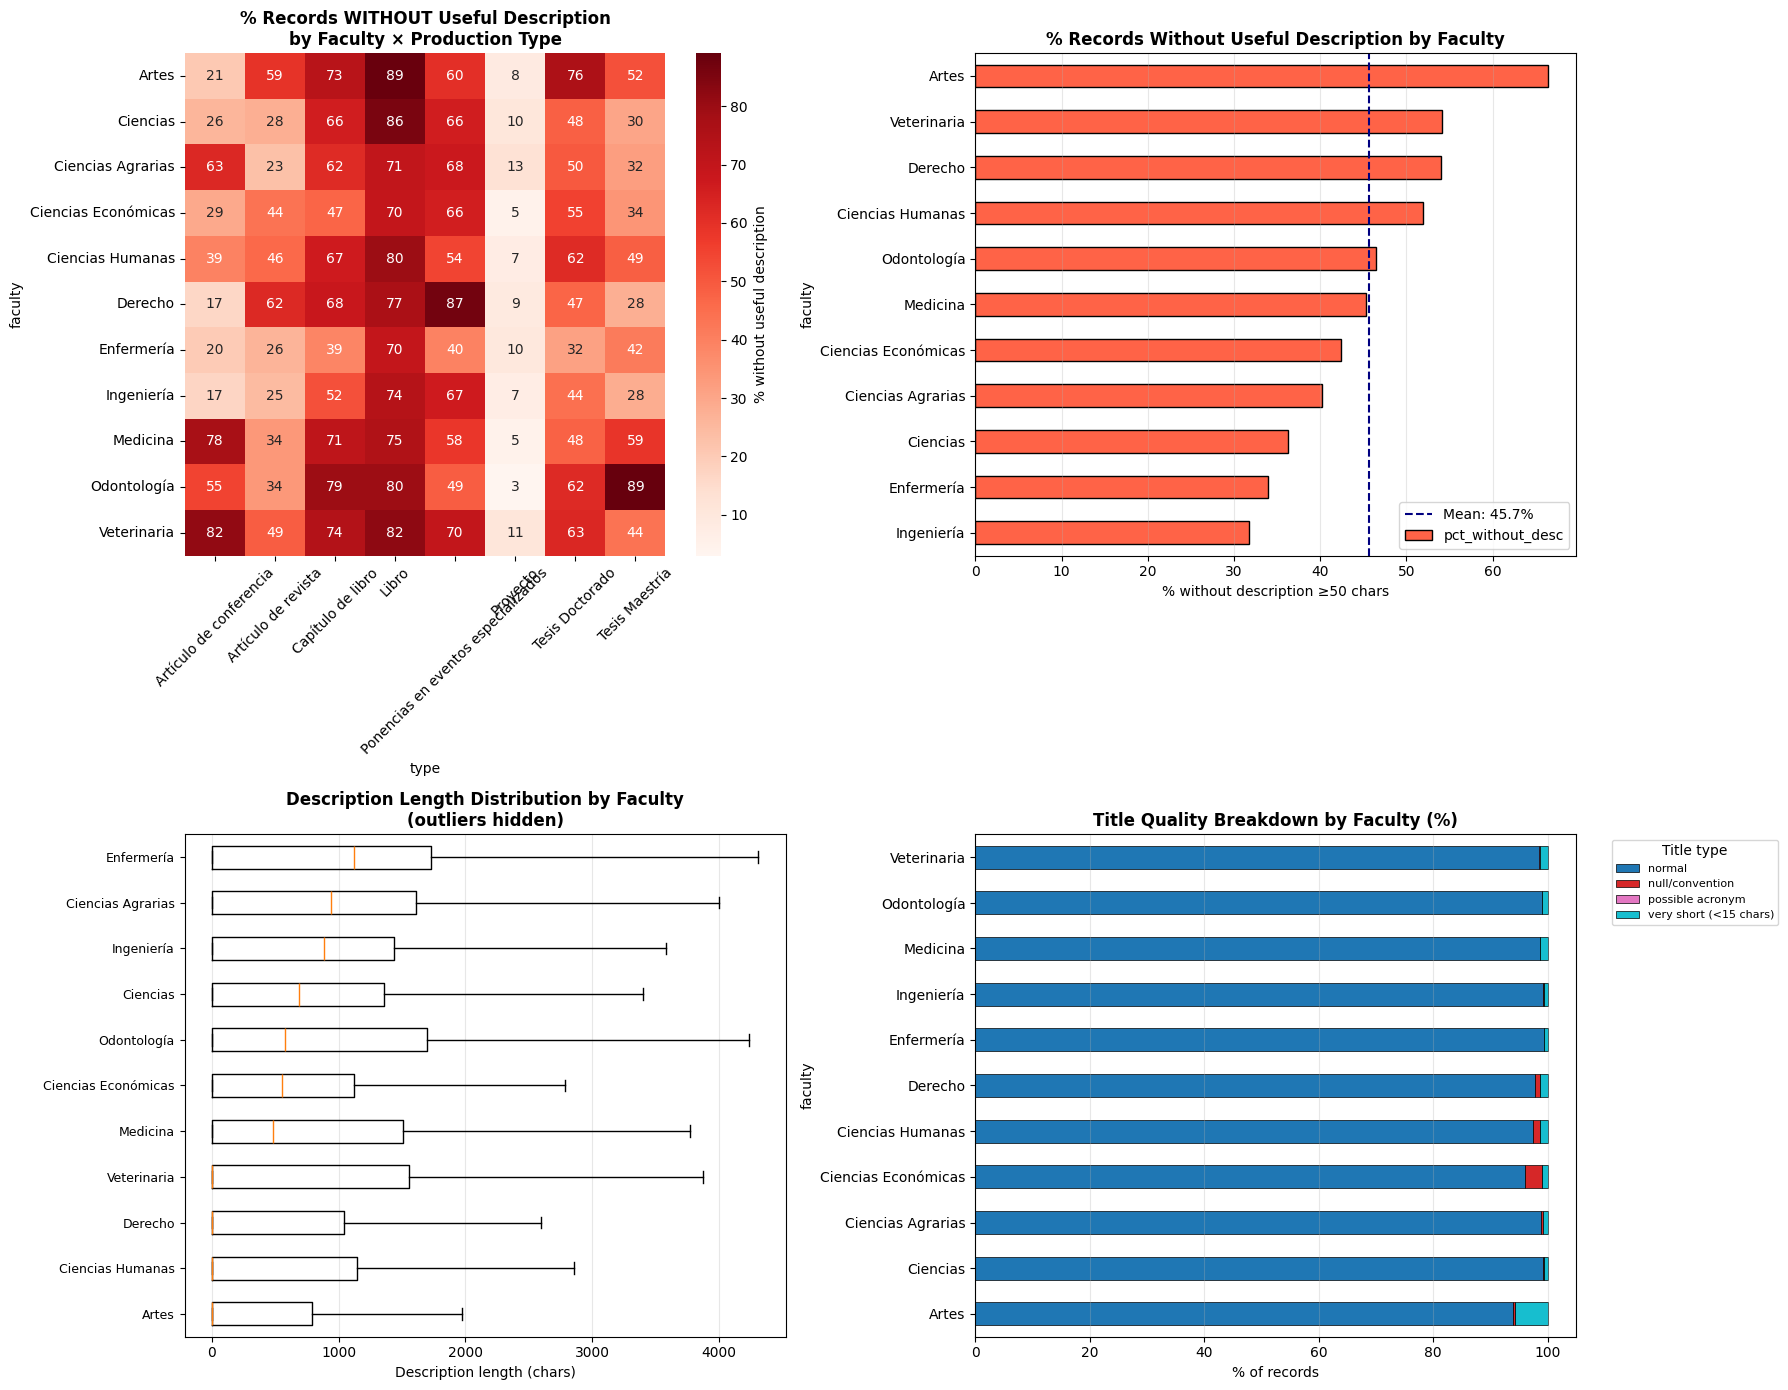


5. Estimated NLP utility by Faculty (records WITH description ≥50 chars):


,total,with_useful_desc,pct_without_desc,pct_util
faculty,,,,
Artes,7107,2386,66.4,33.6
Veterinaria,2975,1366,54.1,45.9
Derecho,4088,1882,54.0,46.0
Ciencias Humanas,9673,4649,51.9,48.1
Odontología,2203,1178,46.5,53.5
Medicina,18982,10382,45.3,54.7
Ciencias Económicas,3481,2005,42.4,57.6
Ciencias Agrarias,4180,2501,40.2,59.8
Ciencias,31948,20362,36.3,63.7



⚠️  Faculties with >60% missing descriptions may be problematic for topic modeling.
   Candidate faculties to consider excluding or flagging: ['Artes']

6. Missing descriptions by Decade:


,total,with_useful_desc,without_desc,pct_without_desc
Decade,,,,
1960,11,5,6,54.5
1970,76,22,54,71.1
1980,802,116,686,85.5
1990,6586,838,5748,87.3
2000,23367,6081,17286,74.0
2010,49248,32919,16329,33.2
2020,21936,18535,3401,15.5


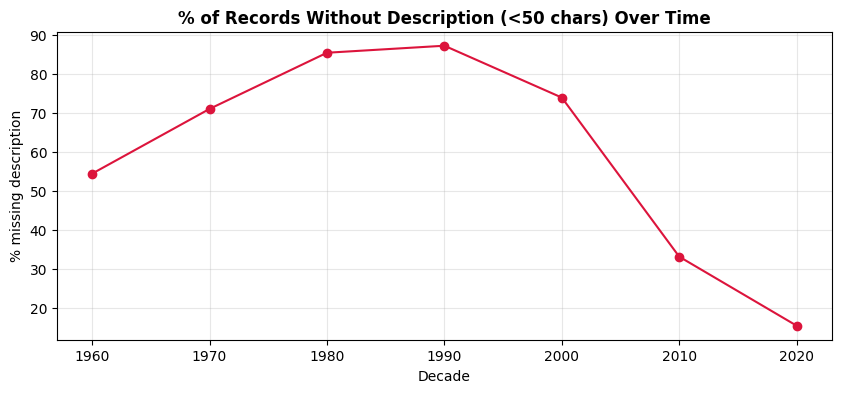

In [16]:
print("=" * 60)
print("MISSING / SHORT CONTENT ANALYSIS BY FACULTY AND TYPE")
print("=" * 60)

# Build a richness profile per record
products_bogota['_has_useful_desc'] = (
    products_bogota['original_description'].notna() &
    ~products_bogota['original_description'].apply(is_convention_null_value) &
    (products_bogota['original_description'].fillna('').str.strip().str.len() >= 50)
)
products_bogota['_has_long_title'] = (
    products_bogota['original_title'].fillna('').str.strip().str.len() >= 15
)
products_bogota['_title_type'] = products_bogota['original_title'].apply(classify_title)

# --- 1. Missing/short descriptions by Faculty ---
print("\n1. Missing/short descriptions by Faculty:")
missing_by_faculty = products_bogota.groupby('faculty').agg(
    total=('_has_useful_desc', 'count'),
    with_useful_desc=('_has_useful_desc', 'sum'),
).assign(
    without_desc=lambda df: df['total'] - df['with_useful_desc'],
    pct_without_desc=lambda df: (df['without_desc'] / df['total'] * 100).round(1)
).sort_values('pct_without_desc', ascending=False)
display(missing_by_faculty)

# --- 2. Missing/short descriptions by type ---
print("\n2. Missing/short descriptions by type:")
missing_by_type = products_bogota.groupby('type').agg(
    total=('_has_useful_desc', 'count'),
    with_useful_desc=('_has_useful_desc', 'sum'),
).assign(
    without_desc=lambda df: df['total'] - df['with_useful_desc'],
    pct_without_desc=lambda df: (df['without_desc'] / df['total'] * 100).round(1)
).sort_values('pct_without_desc', ascending=False)
display(missing_by_type)

# --- 3. Average description length by Faculty ---
products_bogota['_desc_len_real'] = (
    products_bogota['original_description']
    .apply(lambda x: len(str(x).strip()) if pd.notna(x) and not is_convention_null_value(x) else 0)
)
print("\n3. Average description length by Faculty:")
display(
    products_bogota.groupby('faculty')['_desc_len_real']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_desc_len', 'median': 'med_desc_len', 'count': 'n_records'})
    .sort_values('avg_desc_len')
    .round(1)
)

# --- 4. Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Heatmap: % missing description by Faculty x type (top 8 types)
top_types = products_bogota['type'].value_counts().head(8).index
pivot_missing = products_bogota[products_bogota['type'].isin(top_types)].pivot_table(
    index='faculty', columns='type',
    values='_has_useful_desc', aggfunc=lambda x: (1 - x.mean()) * 100
).round(1)
sns.heatmap(pivot_missing, annot=True, fmt='.0f', cmap='Reds',
            ax=axes[0, 0], cbar_kws={'label': '% without useful description'})
axes[0, 0].set_title('% Records WITHOUT Useful Description\nby Faculty × Production Type', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Bar: % missing by faculty
missing_by_faculty['pct_without_desc'].sort_values().plot(
    kind='barh', ax=axes[0, 1], color='tomato', edgecolor='black')
axes[0, 1].set_title('% Records Without Useful Description by Faculty', fontweight='bold')
axes[0, 1].set_xlabel('% without description ≥50 chars')
axes[0, 1].axvline(x=missing_by_faculty['pct_without_desc'].mean(), color='navy',
                    linestyle='--', label=f"Mean: {missing_by_faculty['pct_without_desc'].mean():.1f}%")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Boxplot: description length by Faculty
faculty_order = (
    products_bogota.groupby('faculty')['_desc_len_real']
    .median().sort_values().index
)
box_data = [
    products_bogota[products_bogota['faculty'] == f]['_desc_len_real'].values
    for f in faculty_order
]
axes[1, 0].boxplot(box_data, labels=faculty_order, vert=False, showfliers=False)
axes[1, 0].set_title('Description Length Distribution by Faculty\n(outliers hidden)', fontweight='bold')
axes[1, 0].set_xlabel('Description length (chars)')
axes[1, 0].tick_params(axis='y', labelsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Stacked bar: title type breakdown by faculty
title_type_pivot = products_bogota.pivot_table(
    index='faculty', columns='_title_type', aggfunc='size', fill_value=0
)
title_type_pct = title_type_pivot.div(title_type_pivot.sum(axis=1), axis=0) * 100
title_type_pct.plot(kind='barh', stacked=True, ax=axes[1, 1],
                    colormap='tab10', edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Title Quality Breakdown by Faculty (%)', fontweight='bold')
axes[1, 1].set_xlabel('% of records')
axes[1, 1].legend(title='Title type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# --- 5. NLP utility score ---
print("\n5. Estimated NLP utility by Faculty (records WITH description ≥50 chars):")
utility = missing_by_faculty[['total', 'with_useful_desc', 'pct_without_desc']].copy()
utility['pct_util'] = (100 - utility['pct_without_desc']).round(1)
display(utility.sort_values('pct_util'))

print("\n⚠️  Faculties with >60% missing descriptions may be problematic for topic modeling.")
problematic = utility[utility['pct_without_desc'] > 60].index.tolist()
if problematic:
    print(f"   Candidate faculties to consider excluding or flagging: {problematic}")
else:
    print("   No faculty exceeds 60% missing descriptions threshold.")

# --- 6. Temporal correlation with missing descriptions ---
print("\n6. Missing descriptions by Decade:")
products_bogota['fecha_dt'] = pd.to_datetime(products_bogota['date'], errors='coerce', dayfirst=True)
products_bogota['Decade'] = products_bogota['fecha_dt'].dt.year // 10 * 10

missing_by_decade = products_bogota.dropna(subset=['Decade']).groupby('Decade').agg(
    total=('_has_useful_desc', 'count'),
    with_useful_desc=('_has_useful_desc', 'sum')
).assign(
    without_desc=lambda df: df['total'] - df['with_useful_desc'],
    pct_without_desc=lambda df: (df['without_desc'] / df['total'] * 100).round(1)
).sort_index()

display(missing_by_decade)

fig_temp, ax_temp = plt.subplots(figsize=(10, 4))
missing_by_decade['pct_without_desc'].plot(kind='line', marker='o', color='crimson', ax=ax_temp)
ax_temp.set_title('% of Records Without Description (<50 chars) Over Time', fontweight='bold')
ax_temp.set_xlabel('Decade')
ax_temp.set_ylabel('% missing description')
ax_temp.grid(True, alpha=0.3)
plt.show()

products_bogota.drop(columns=['fecha_dt', 'Decade'], inplace=True, errors='ignore')

# Cleanup helper columns
products_bogota.drop(columns=['_has_useful_desc', '_has_long_title', '_title_type',
                                '_desc_len_real'], inplace=True, errors='ignore')

### 2.1.7. Missing Value Treatment

In [17]:
print("=" * 60)
print("MISSING VALUE TREATMENT")
print("=" * 60)


def is_useful_text(val, min_chars=10):
    """Returns True if the value is a non-null, non-convention string with enough content."""
    if is_convention_null_value(val):
        return False
    return len(str(val).strip()) >= min_chars

# --- Audit before treatment ---
no_title = ~products_bogota['original_title'].apply(is_useful_text)
no_desc = ~products_bogota['original_description'].apply(lambda x: is_useful_text(x, min_chars=50))

print(f"Records without usable title: {no_title.sum()}")
print(f"Records without usable description (≥50 chars): {no_desc.sum()}")
print(f"Records with neither: {(no_title & no_desc).sum()}")

# --- Strategy ---
# 1. Records with no title AND no description → drop (nothing usable for modeling)
mask_drop = (
    products_bogota['original_title'].isna() &
    products_bogota['original_description'].isna()
)
print(f"\nDropping {mask_drop.sum()} records with no title and no description.")
products_bogota = products_bogota[~mask_drop].reset_index(drop=True)

# 2. Create combined text column (title + description) — used in both pipelines
def combine_title_description(row):
    title = str(row['original_title']).strip() if pd.notna(row['original_title']) else ''
    desc = str(row['original_description']).strip() if pd.notna(row['original_description']) else ''
    if title and desc:
        return title + '. ' + desc
    return title or desc

products_bogota['combined_text'] = products_bogota.apply(combine_title_description, axis=1)

print(f"\nRecords remaining: {len(products_bogota)}")
print(f"Records using title-only (no description): {products_bogota['original_description'].isna().sum()}")
print(f"Combined text column created: 'combined_text'")
print(f"Sample:\n{products_bogota['combined_text'].iloc[0][:300]}")

MISSING VALUE TREATMENT
Records without usable title: 837
Records without usable description (≥50 chars): 43510
Records with neither: 626

Dropping 264 records with no title and no description.

Records remaining: 101762
Records using title-only (no description): 43120
Combined text column created: 'combined_text'
Sample:
La producción de conocimiento a través de la investigación académica está siendo cada vez más exigida y cuestionada, en un entorno de crisis socio-económica e institucional generalizada de la Universidad. Por su parte, la investigación académica se ve exigida para dar respuesta a las presiones y nec


### 2.1.8. Feature engineering
**Purpose:** Handles basic type exclusions.

#### 2.1.8.1. Type analysis

In [18]:
print("=" * 60)
print("VECTOR SPACE PROTECTION: ROW-LEVEL PURGING")
print("=" * 60)

# The base list of noisy administrative types
types_to_drop = ['Errata', 'Comentario', 'Editorial', 'Datos']

# We flag a row for deletion ONLY IF it is in the drop list AND it has exactly 0 citations.
mask_to_drop = products_bogota['type'].isin(types_to_drop) & (products_bogota['citations'] == 0)

n_purged = mask_to_drop.sum()
products_bogota = products_bogota[~mask_to_drop].copy().reset_index(drop=True)

print(f"Purged {n_purged} noisy administrative records.")

VECTOR SPACE PROTECTION: ROW-LEVEL PURGING
Purged 365 noisy administrative records.


### 2.1.9. Language Detection

**Purpose:** Identifies text language using Lingua.

**Insight:** Crucial because the Classical NLP pipeline strictly supports English/Spanish and breaks on unexpected language lemmatization.

#### Diagnostics: Analysis of Suspect Raw Language Labels
We observed that thousands of records were originally tagged with languages like "Galicia", "Indonesio", or "Lituano". Sampling them proves they are overwhelmingly Spanish records misclassified by upstream systems. This justifies explicitly treating all labels other than 'Español' and 'Inglés' as untrusted and forcing a new detection layer.

In [19]:
print("=" * 60)
print("ANALYSIS OF SUSPECT RAW LANGUAGE LABELS")
print("=" * 60)

suspicious_languages = ['Galicia', 'Indonesio', 'Lituano', 'Rumania', 'Vasco', 'Catalán', 'Africanos']
mask_suspicious = products_bogota['language'].isin(suspicious_languages)

if mask_suspicious.sum() > 0:
    print(f"Found {mask_suspicious.sum()} records with highly suspicious base languages.")
    print("Sample of these suspicious records:")
    display(
        products_bogota[mask_suspicious][['original_title', 'original_description', 'language']]
        .sample(min(8, mask_suspicious.sum()), random_state=42)
    )
    print("\nConclusion: The external classifier used upstream was highly inaccurate.")
    print("Decision: Any language other than Español and Inglés will be swept by our Lingua detector.")

ANALYSIS OF SUSPECT RAW LANGUAGE LABELS
Found 1906 records with highly suspicious base languages.
Sample of these suspicious records:


,original_title,original_description,language
65963,Meha Priyadarshini. Chinese Porcelain in Colon...,NaN,Indonesio
5980,Análisis estadístico de datos categóricos,NaN,Galicia
98089,Uncovering Immunological Readouts Useful To Pr...,NaN,Indonesio
88358,Simulacion de la educacion k.p.z. (kardar-pari...,NaN,Vasco
23593,Dermatomiositis Sin Compromiso Muscular Inicia...,NaN,Indonesio
72322,Ocupación como proceso sociocultural,NaN,Galicia
4108,Alimentos transgenicos o la subversion quimeri...,NaN,Galicia
29604,Doutor em engenharia area de concentracao: eng...,NaN,Galicia



Conclusion: The external classifier used upstream was highly inaccurate.
Decision: Any language other than Español and Inglés will be swept by our Lingua detector.


In [20]:
print("=" * 60)
print("LANGUAGE DETECTION (Lingua)")
print("=" * 60)

try:
    HAS_LINGUA = True
    print("lingua-language-detector available.")
except ImportError:
    HAS_LINGUA = False
    print("⚠️  lingua not installed. Run: pip install lingua-language-detector")
    print("   Falling back to langdetect.")

# --- Build Lingua detector ---
LINGUA_LANGUAGES = [
    Language.SPANISH, Language.ENGLISH, Language.FRENCH,
    Language.PORTUGUESE, Language.GERMAN, Language.ITALIAN,
]

LANG_CODE_MAP = {
    'SPANISH': 'Español', 'ENGLISH': 'Inglés', 'FRENCH': 'Francés',
    'PORTUGUESE': 'Portugués', 'GERMAN': 'Alemán', 'ITALIAN': 'Italiano',
}

if HAS_LINGUA:
    detector = (
        LanguageDetectorBuilder
        .from_languages(*LINGUA_LANGUAGES)
        .with_minimum_relative_distance(0.15)  # confidence threshold
        .build()
    )

def detect_language_lingua(title, description, journal, min_chars=20):
    """
    Detect language using Lingua.
    Strategy: use description if long enough, otherwise combine title + description.
    Fallback: If text is too short or Lingua is unconfident, use 'journal_conference'
    name as a hint (e.g., for short German titles).
    """
    desc_str = str(description).strip() if pd.notna(description) and not is_convention_null_value(description) else ''
    title_str = str(title).strip() if pd.notna(title) and not is_convention_null_value(title) else ''
    journal_str = str(journal).strip() if pd.notna(journal) and not is_convention_null_value(journal) else ''

    detection_text = ""
    # Prefer description (longer, more representative)
    if len(desc_str) >= 20:
        detection_text = desc_str
    elif len(desc_str) >= min_chars:
        detection_text = f"{title_str} {desc_str}".strip()
    elif len(title_str) >= min_chars:
        detection_text = title_str

    result = None
    if detection_text:
        result = detector.detect_language_of(detection_text)

    # Fallback to Journal/Conference if standard detection failed (too short or unconfident)
    if result is None and len(journal_str) >= 10:
        result = detector.detect_language_of(journal_str)

    if result is None:
        return 'Unknown'

    lang_name = result.name  # e.g. 'SPANISH'
    return LANG_CODE_MAP.get(lang_name, f'Other ({lang_name.title()})')


# --- Detect where language is missing OR is not a trusted base language ---
# Raw labels like 'Galicia', 'Indonesio', 'Lituano', etc. are highly corrupted.
trusted_languages = ['Español', 'Inglés', 'Spanish', 'English']
mask_to_detect = products_bogota['language'].isna() | ~products_bogota['language'].isin(trusted_languages)

print(f"Records needing language detection (missing or untrusted label): {mask_to_detect.sum()}")
print("Running language detection (this may take a moment)...")

products_bogota.loc[mask_to_detect, 'language'] = [
    detect_language_lingua(t, d, j)
    for t, d, j in zip(
        products_bogota.loc[mask_to_detect, 'original_title'],
        products_bogota.loc[mask_to_detect, 'original_description'],
        products_bogota.loc[mask_to_detect, 'journal_conference']
    )
]

# --- Also re-detect where the existing label might be based on title only ---
# (This corrects cases where a Spanish abstract was labeled 'Inglés' due to English title)
print("\nRe-checking records labeled as 'Inglés' that have a Spanish description...")
mask_english = products_bogota['language'] == 'Inglés'
mask_long_desc = products_bogota['original_description'].fillna('').str.len() >= 20

suspects = mask_english & mask_long_desc
print(f"  Candidates (English label + long description): {suspects.sum()}")

corrections = []
suspect_descriptions = products_bogota.loc[suspects, 'original_description']
suspect_journals = products_bogota.loc[suspects, 'journal_conference']
for idx, (desc, journal) in zip(suspects[suspects].index, zip(suspect_descriptions, suspect_journals)):
    desc_lang = detect_language_lingua('', desc, journal)
    if desc_lang not in ('Inglés', 'Unknown'):
        corrections.append((idx, 'Inglés', desc_lang))

print(f"  Records where description language differs from title: {len(corrections)}")
if corrections:
    print("  Sample corrections:")
    for idx, before, after in corrections[:10]:
        title_sample = products_bogota.at[idx, 'original_title']
        print(f"    [{idx}] '{title_sample[:60]}...' → {before} → {after}")

    # Apply corrections efficiently
    for idx, _, new_lang in corrections:
        products_bogota.at[idx, 'language'] = new_lang
    print(f"  Applied {len(corrections)} language corrections.")

print("\nFinal language distribution:")
display(
    products_bogota['language'].value_counts(dropna=False)
    .to_frame("count")
    .assign(pct=lambda df: (df['count'] / len(products_bogota) * 100).round(2))
)

LANGUAGE DETECTION (Lingua)
lingua-language-detector available.
Records needing language detection (missing or untrusted label): 11532
Running language detection (this may take a moment)...

Re-checking records labeled as 'Inglés' that have a Spanish description...
  Candidates (English label + long description): 28128
  Records where description language differs from title: 258
  Sample corrections:
    [265] '20 years' journey of the profile journal in ELT research...' → Inglés → Español
    [831] 'A facile approach toward 8-o-4'-neolignans: synthesis of thr...' → Inglés → Español
    [1121] 'A model for addressing the chronic disease care burden in Co...' → Inglés → Español
    [1199] 'A multiscale for mulation for FEM and IgA...' → Inglés → Español
    [1254] 'A new genus and two new species of Apomecynini, a new specie...' → Inglés → Español
    [1315] 'A New Species of Eranina Monné, 2005 (Coleoptera: Cerambycid...' → Inglés → Español
    [1421] 'A note on zip and reversible skew

,count,pct
language,,
Español,61007,60.17
Inglés,36990,36.48
Unknown,1717,1.69
Portugués,679,0.67
Francés,406,0.40
Alemán,302,0.30
Italiano,296,0.29


In [21]:
# After language detection — cross-check with faculty
print("Language × Faculty cross-table (sanity check):")
lang_fac = pd.crosstab(
    products_bogota['faculty'],
    products_bogota['language'],
    normalize='index'
).round(3) * 100

display(lang_fac)

print("\n⚠️  Faculties where English > 70% of publications (flag for review):")
if 'Inglés' in lang_fac.columns:
    display(lang_fac[lang_fac['Inglés'] > 70][['Inglés']])

Language × Faculty cross-table (sanity check):


language,Alemán,Español,Francés,Inglés,Italiano,Portugués,Unknown
faculty,,,,,,,
Artes,0.6,79.6,0.9,7.0,1.5,0.7,9.8
Ciencias,0.2,47.7,0.1,50.3,0.2,0.5,0.9
Ciencias Agrarias,0.2,63.2,0.0,35.0,0.1,0.7,0.7
Ciencias Económicas,0.1,64.6,0.8,33.0,0.2,0.2,1.2
Ciencias Humanas,0.5,77.5,1.3,17.4,0.3,0.8,2.0
Derecho,2.0,88.8,0.8,7.1,0.1,0.5,0.8
Enfermería,0.0,75.0,0.0,22.8,0.0,1.2,0.8
Ingeniería,0.2,51.9,0.3,46.3,0.1,0.3,0.8
Medicina,0.1,60.9,0.3,36.4,0.3,0.9,1.2



⚠️  Faculties where English > 70% of publications (flag for review):


language,Inglés
faculty,


In [22]:
print("=" * 60)
print("DEFAULTING 'DESCONOCIDO' LANGUAGE RECORDS")
print("=" * 60)
print("Defaulting 'Unknown' to 'Español' since UNAL is a Spanish-speaking institution,")
print("and most Lingua fallbacks are short titles lacking enough signal > 0.15 distance.\n")

mask_desc = products_bogota['language'] == 'Unknown'
print(f"Total 'Unknown' records defaulted to 'Español': {mask_desc.sum()}")

if mask_desc.sum() > 0:
    print("Sample of records defaulted to 'Español':")
    display(
        products_bogota[mask_desc][['original_title', 'original_description', 'faculty']]
        .sample(min(10, mask_desc.sum()), random_state=42)
    )
    
products_bogota.loc[mask_desc, 'language'] = 'Español'

DEFAULTING 'DESCONOCIDO' LANGUAGE RECORDS
Defaulting 'Unknown' to 'Español' since UNAL is a Spanish-speaking institution,
and most Lingua fallbacks are short titles lacking enough signal > 0.15 distance.

Total 'Unknown' records defaulted to 'Español': 1717
Sample of records defaulted to 'Español':


,original_title,original_description,faculty
45906,Feria moreu,NaN,Ciencias Humanas
83677,Religion und mythologie der ui,NaN,Ciencias Humanas
8630,Articulos publicados,NaN,Artes
9927,AZUR,NaN,Artes
22679,De los ítem,NaN,Enfermería
50879,Hipertension Y,NaN,Medicina
92034,Superando en estigma contratista.,NaN,Derecho
15429,Charlotte salomon vida o teatro?,NaN,Artes
85073,Revision taxonomica de la subtribu myrciinae o...,NaN,Ciencias
63130,Magister en biologia - area biodiversidad y me...,NaN,Ciencias


### 2.1.10. Embeddings Pipeline — Final Summary
**Purpose:** Generates the raw `embeddings_text` vectorization string.

**Insight:** Uses **Prefix Serialization** (`[{faculty}] {type}: {Title}...`) to bridge the semantic gap for highly metaphorical or short records (e.g., Arts/Software projects).

In [23]:
# Summary of the embeddings-ready column
print("=" * 60)
print("EMBEDDINGS PIPELINE — FINAL TEXT SUMMARY")
print("=" * 60)

products_bogota['embeddings_text'] = products_bogota['combined_text']

exclusion_list = [
    'Universidad Nacional de Colombia', 'NaN', 'Memorias', 'Bogotá', 'Medellín', 'Revista de la faculty de Medicína', 'Ingenium Revista de la faculty de Ingeniería', 'Revista faculty de Ciencias Economicas', 'Revista de la faculty de Odontología Universidad de Antioquia', 'Revista faculty de Ingeniería Universidad de Antioquia', 'Avances de Investigación en la faculty de Enfermería', 'Trayectoria de Investigación de la faculty de Enfermería Hechos y Realidades', 
    'Colombia.', 'Repositorio Institucional', 'Biblioteca Digital', 'Trabajo de Grado', 'Ingeniería e Investigación', 'Revista Ica', 
    'Tesis y Disertaciones.', 'N/A', 'Sin publicar', 'Unknown', '-', 'Memórias do Instituto Oswaldo Cruz', 'Vitae', 'Revista Udca Actualidad & Divulgación Científica', 'Universidad Nacional de Colombia. faculty de Artes,',
    'Arxiv', 'Preprints', 'Proceedings', 'Conference Proceedings', 'Documento Cede', 'Caldasia', 'Dyna', 'Momento', 'Congreso Iberoamericano de Iluminación',
    'Documentos Fce Escuela de Economía', 'El Tiempo', 'El Espectador Magazin Dominical', 'Revista Innovar Journal', 'Scientific Reports',
    'Cien Dias', 'Universidad Nacional de Colombia. faculty de Artes,', 'National Survey of Scientific Manpower', 'Forma y Funcion',
    'Contaduria Universidad de Antioquia', 'Aog K Cg K C', 'Cs', 'Cucli Cucli Numero', 'Plos One', 'Colombia Internacional', 'Revista faculty de Ingeniería Universidad de Antioquia ( Medellín )',
]
exclusion_set = {str(x).lower().strip() for x in exclusion_list}

def build_contextual_text(row):
    fac = str(row.get('faculty', '')).strip() if pd.notna(row.get('faculty')) else ''
    tipo = str(row.get('type', '')).strip() if pd.notna(row.get('type')) else ''
    tit = str(row.get('original_title', '')).strip() if pd.notna(row.get('original_title')) else ''
    desc = str(row.get('original_description', '')).strip() if pd.notna(row.get('original_description')) else ''
    
    rev_raw = str(row.get('journal_conference', '')).strip() if pd.notna(row.get('journal_conference')) else ''
    rev = rev_raw if rev_raw and rev_raw.lower() not in exclusion_set else None
    
    parts = []
    
    # 1. Prefix: Macro-domain pseudotokens
    if fac and tipo:
        parts.append(f"[{fac}] {tipo}:")
    elif fac:
        parts.append(f"[{fac}]:")
    elif tipo:
        parts.append(f"[{tipo}]:")
        
    # 2. Body: Natural Language (Title and Description)
    text_body = ""
    if tit and desc:
        text_body = f"{tit} {desc}" if tit.endswith('.') else f"{tit}. {desc}"
    elif tit:
        text_body = tit
    elif desc:
        text_body = desc
        
    if text_body:
        parts.append(text_body)
        
    # 3. Suffix: Journal formatting
    if rev:
        if parts and not parts[-1].endswith('.'):
             parts[-1] += "."
        parts.append(f"Publicado en {rev}.")
        
    return " ".join(parts).strip()

products_bogota['embeddings_text'] = products_bogota.apply(build_contextual_text, axis=1)

emb_summary = pd.DataFrame({
    'total_records': [len(products_bogota)],
    'usable_texts': [(products_bogota['embeddings_text'].str.strip() != '').sum()],
    'mean_length_chars': [products_bogota['embeddings_text'].str.len().mean().round(0)],
    'median_length_chars': [products_bogota['embeddings_text'].str.len().median()],
})
display(emb_summary)

print("\nSample (embeddings_text):")
for i in range(3):
    print(f"\n[{i}] {products_bogota['embeddings_text'].iloc[i][:300]}")
    print("-" * 60)

EMBEDDINGS PIPELINE — FINAL TEXT SUMMARY


,total_records,usable_texts,mean_length_chars,median_length_chars
0,101397,101397,1007.0,748.0



Sample (embeddings_text):

[0] [Ciencias Económicas] Artículo de revista: La producción de conocimiento a través de la investigación académica está siendo cada vez más exigida y cuestionada, en un entorno de crisis socio-económica e institucional generalizada de la Universidad. Por su parte, la investigación académica se ve exigi
------------------------------------------------------------

[1] [Ciencias Económicas] Artículo de revista: Fruto de un proceso de interacción de más de seis meses, el pasado 2 de diciembre de 2016 se formalizó la creación de la Red de Estudios Organizacionales Colombiana (REOC). Esta iniciativa, impulsada por profesores de las Universidades EAFIT, del Rosario y 
------------------------------------------------------------

[2] [Ciencias Económicas] Artículo de revista: Al cierre de la presente edición de INNOVAR, la ciudadanía en Latinoamérica y Colombia se encuentra consternada frente a los hechos de corrupción público-privada que han sido conocidos por la

## 2.2. Preprocessing for classical NLP (LDA / TF-IDF Pipeline)

**Purpose:** Second pipeline branch optimized for sparse baseline models like Gensim LDA.

**Insight:** Implements heavy text reduction: tokenization, lemmatization (spaCy), and domain-specific stopword removal.

### 2.2.1. Load spaCy Models


In [24]:
try:
    nlp_es = spacy.load('es_core_news_md', disable=['parser', 'ner'])
    print("Spanish spaCy model loaded.")
except OSError:
    nlp_es = None
    print("⚠️ Spanish spaCy model not found. Run: python -m spacy download es_core_news_md")
    raise

try:
    nlp_en = spacy.load('en_core_web_md', disable=['parser', 'ner'])
    print("English spaCy model loaded.")
except OSError:
    nlp_en = None
    print("⚠️ English spaCy model not found. Run: python -m spacy download en_core_web_md")
    raise

Spanish spaCy model loaded.
English spaCy model loaded.


### 2.2.2. Stopwords lists

In [25]:
# Combine NLTK stopwords for Spanish and English
stop_es = set(stopwords.words('spanish'))
stop_en = set(stopwords.words('english'))

# Domain-specific stopwords (academic boilerplate)
stop_domain = {
    'estudio', 'trabajo', 'artículo', 'paper', 'article', 'research',
    'resultado', 'resultados', 'results', 'method', 'methods', 'método', 'métodos',
    'análisis', 'analysis', 'caso', 'casos', 'case', 'objetivo', 'objectives',
    'conclusión', 'conclusiones', 'conclusion', 'conclusions',
    'propuesta', 'propuesto', 'proposed', 'approach', 'study', 'show', 'shown',
    'present', 'presenta', 'presentamos', 'identified', 'identificado',
    'también', 'además', 'however', 'furthermore', 'thus', 'therefore'
}

STOPWORDS_COMBINED = stop_es | stop_en | stop_domain
print(f"Total stopwords: {len(STOPWORDS_COMBINED)}")

Total stopwords: 545


### 2.2.3. Core Classical Text Pipeline

In [26]:
# 1. PRECOMPILE REGEX (Done once in memory)
PUNCT_PATTERN = re.compile(r'[^\w\s-]')
NUM_PATTERN = re.compile(r'\b\d+\b')
SPACE_PATTERN = re.compile(r'\s+')

def pre_regex_cleaning(text):
    """Quick string cleaning before passing to spaCy."""
    if pd.isna(text) or str(text).strip() == '':
        return ""
    text = str(text).lower()
    text = PUNCT_PATTERN.sub(' ', text)
    text = NUM_PATTERN.sub(' ', text)
    text = SPACE_PATTERN.sub(' ', text)
    return text.strip()

print("1. Applying preliminary Regex cleaning...")
tqdm.pandas(desc="Regex pre-cleaning")
products_bogota['clean_text'] = products_bogota['combined_text'].progress_apply(pre_regex_cleaning)

# 2. SPLIT BY LANGUAGE FOR BATCH PROCESSING
# Assume Spanish by default if not labeled as English
mask_en = products_bogota['language'].astype(str).str.lower().str.contains('inglés', na=False)
mask_es = ~mask_en

def extract_tokens_spacy(texts_iterable, nlp_model, min_token_len=3):
    """Process texts in batch using nlp.pipe and return list-of-token-lists."""
    # n_process=-1 uses all cores (may not work in some notebook setups). batch_size can be tuned (500-1000 is ideal)
    docs = nlp_model.pipe(texts_iterable, batch_size=500, n_process=1)
    
    tokens_list = []
    for doc in tqdm(docs, total=len(texts_iterable), desc="spaCy Pipe processing"):
        tokens = [
            token.lemma_.strip()  # preliminary cleaning already lowercased text
            for token in doc
            if not token.is_stop
            and not token.is_space
            and token.is_alpha
            and len(token.lemma_) >= min_token_len
            and token.lemma_ not in STOPWORDS_COMBINED
        ]
        tokens_list.append(tokens)
    return tokens_list

print("\n2. Processing batch in Spanish...")
if nlp_es:
    texts_es = products_bogota.loc[mask_es, 'clean_text'].tolist()
    tokens_es = extract_tokens_spacy(texts_es, nlp_es)
    # Assign back using original index
    products_bogota.loc[mask_es, 'tokens'] = pd.Series(tokens_es, index=products_bogota[mask_es].index)

print("\n3. Processing batch in English...")
if nlp_en:
    texts_en = products_bogota.loc[mask_en, 'clean_text'].tolist()
    tokens_en = extract_tokens_spacy(texts_en, nlp_en)
    products_bogota.loc[mask_en, 'tokens'] = pd.Series(tokens_en, index=products_bogota[mask_en].index)

# (Optional) If a model failed to load, apply a basic fallback:
failures = products_bogota['tokens'].isna()
if failures.any():
    print(f"\n⚠️ Applying basic fallback to {failures.sum()} records...")
    products_bogota.loc[failures, 'tokens'] = products_bogota.loc[failures, 'clean_text'].apply(
        lambda x: [t for t in x.split() if t.isalpha() and len(t) >= 3 and t not in STOPWORDS_COMBINED]
    )

products_bogota['classic_text'] = products_bogota['tokens'].apply(lambda t: ' '.join(t))
print("Tokenization and lemmatization completed")

1. Applying preliminary Regex cleaning...


Regex pre-cleaning: 100%|██████████| 101397/101397 [00:08<00:00, 11595.89it/s]



2. Processing batch in Spanish...


spaCy Pipe processing: 100%|██████████| 64407/64407 [11:53<00:00, 90.21it/s]  



3. Processing batch in English...


spaCy Pipe processing: 100%|██████████| 36990/36990 [09:22<00:00, 65.71it/s]  


Tokenization and lemmatization completed


### 2.2.4. N-Gram Extraction and Build Per-Document N-Gram Tokens
**Purpose:** Fuses high-frequency word pairs/triplets (e.g., 'machine' + 'learning' -> 'machine_learning') using Gensim Phrases.

In [27]:
print("=" * 60)
print("N-GRAM EXTRACTION (Gensim Phrases)")
print("=" * 60)

# 1. Prepare the corpus (list of token lists)
# Gensim expects a list of documents (each document = list of tokens).
sentences = products_bogota['tokens'].tolist()

print("Training bigram model...")
# min_count: ignore tokens that appear fewer than 10 times in the corpus
# threshold: minimum score to consider two words a bigram (higher = more strict)
bigram_model = Phrases(sentences, min_count=10, threshold=10.0)

# Phraser is a memory-efficient wrapper
bigram_phraser = Phraser(bigram_model)

print("Training trigram model on top of bigrams...")
# For trigrams, pass the corpus already transformed with bigrams
# This detects sequences like 'support_vital' + 'advanced' -> 'support_vital_advanced'
trigram_model = Phrases(bigram_phraser[sentences], min_count=5, threshold=10.0)
trigram_phraser = Phraser(trigram_model)

# 2. Apply the models to the DataFrame
print("Applying n-grams to the dataset...")
tqdm.pandas(desc="Generating n-grams")

def apply_ngrams(tokens):
    """Apply bigram and trigram rules to a list of tokens."""
    if not tokens:
        return []
    # Pass through bigram phraser then trigram phraser
    return trigram_phraser[bigram_phraser[tokens]]

products_bogota['tokens_ngrams'] = products_bogota['tokens'].progress_apply(apply_ngrams)

# 3. Create the final string for TF-IDF
products_bogota['classic_text_ngrams'] = products_bogota['tokens_ngrams'].apply(lambda t: ' '.join(t))

all_tokens = [token for token_list in products_bogota['tokens_ngrams'] for token in token_list]

print("Column 'tokens_ngrams' and 'classic_text_ngrams' created successfully")
print(f"Sample (record 0): {products_bogota['tokens_ngrams'].iloc[0][:20]}")

N-GRAM EXTRACTION (Gensim Phrases)
Training bigram model...
Training trigram model on top of bigrams...
Applying n-grams to the dataset...


Generating n-grams: 100%|██████████| 101397/101397 [00:12<00:00, 7819.29it/s]


Column 'tokens_ngrams' and 'classic_text_ngrams' created successfully
Sample (record 0): ['producción_conocimiento', 'investigación', 'académico', 'exigido', 'cuestionado', 'entorno', 'crisis', 'institucional', 'generalizado', 'universidad', 'investigación', 'académico', 'ver', 'exigido', 'respuesta', 'presión', 'necesidad', 'entorno', 'concretamente', 'prioridad']


# 3. Visualization: Classical vs Embeddings Pipeline Comparison

**Purpose:** Visually validates the destructive nature of the Classical pipeline versus the structure-preserving Embeddings pipeline.

VISUALIZATION — PIPELINE COMPARISON


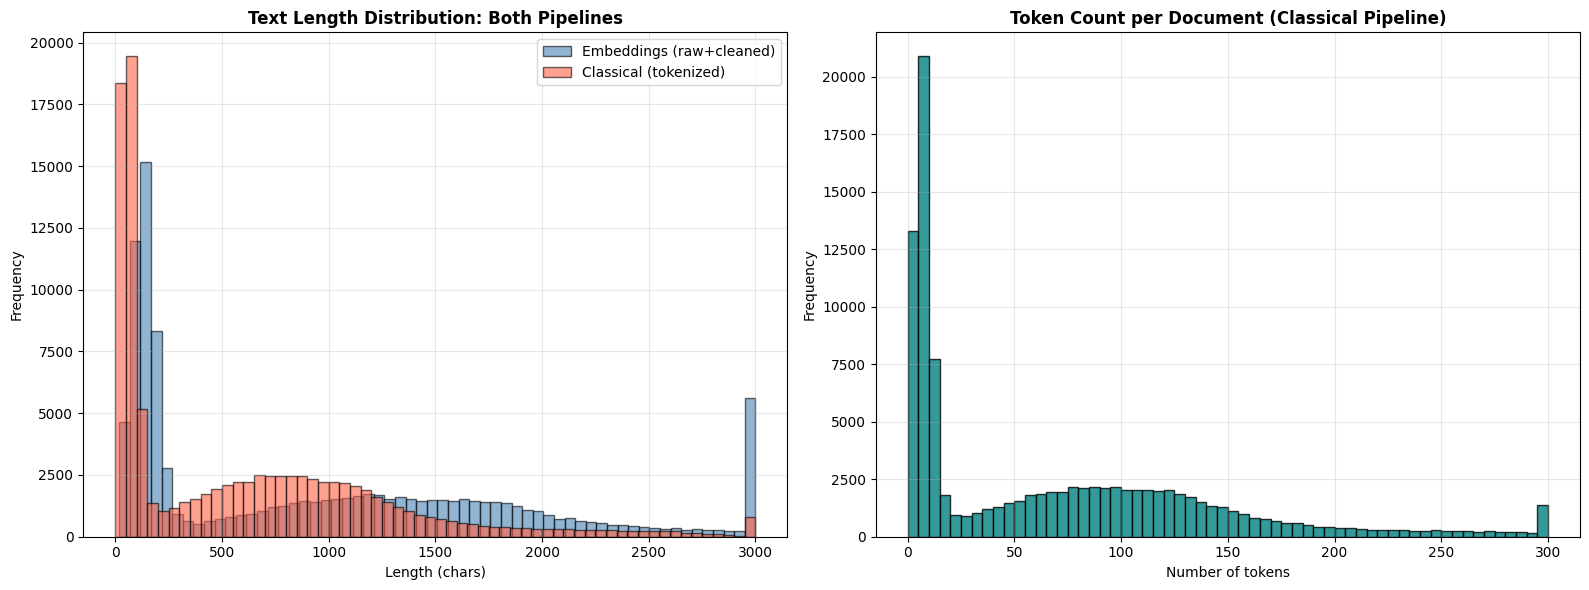

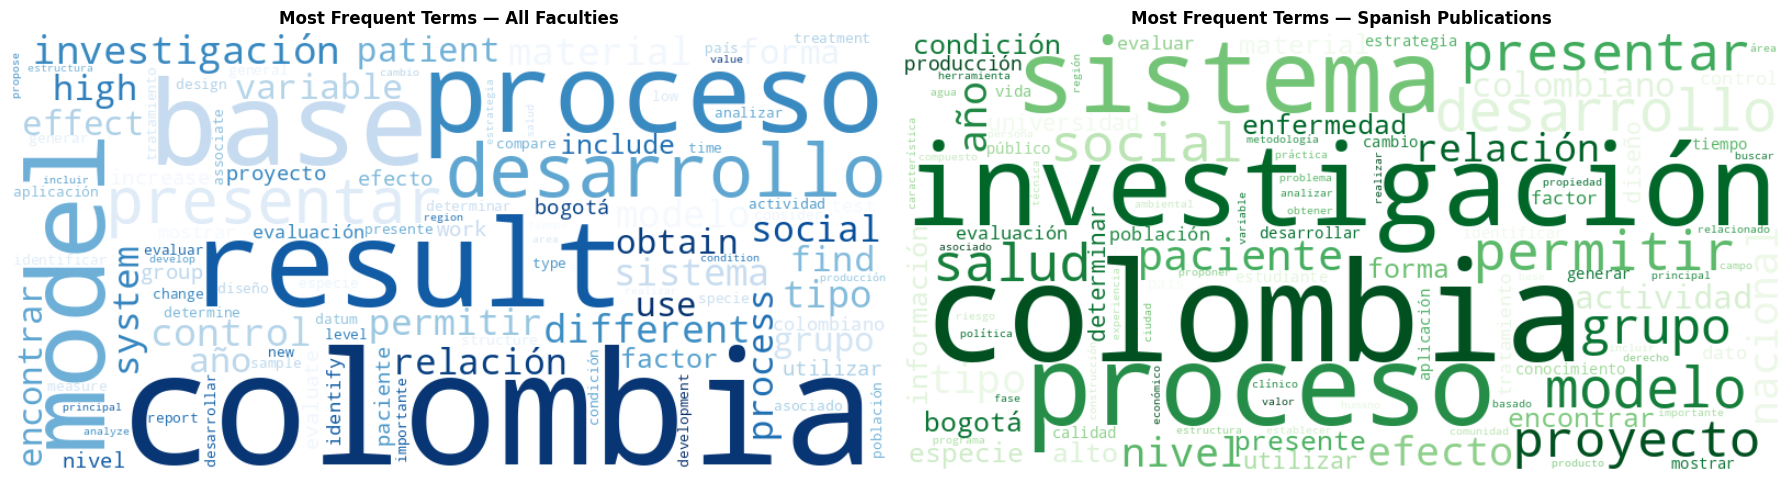

In [28]:
print("=" * 60)
print("VISUALIZATION — PIPELINE COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Text length: raw combined vs classical processed ---
len_raw = products_bogota['embeddings_text'].str.len()
len_classic = products_bogota['classic_text'].str.len()

axes[0].hist(len_raw.clip(upper=3000), bins=60, alpha=0.6, label='Embeddings (raw+cleaned)', color='steelblue', edgecolor='black')
axes[0].hist(len_classic.clip(upper=3000), bins=60, alpha=0.6, label='Classical (tokenized)', color='tomato', edgecolor='black')
axes[0].set_title('Text Length Distribution: Both Pipelines', fontweight='bold')
axes[0].set_xlabel('Length (chars)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Token count per document ---
n_tokens = products_bogota['tokens'].apply(len)
axes[1].hist(n_tokens.clip(upper=300), bins=60, color='teal', edgecolor='black', alpha=0.8)
axes[1].set_title('Token Count per Document (Classical Pipeline)', fontweight='bold')
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Most frequent terms (WordClouds) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

freq_dict = Counter(all_tokens)

wc_all = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='Blues').generate_from_frequencies(freq_dict)
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('Most Frequent Terms — All Faculties', fontweight='bold')
axes[0].axis('off')

# Language-specific: Spanish only
tokens_es = [
    t for tokens, language in zip(products_bogota['tokens'], products_bogota['language'])
    for t in tokens
    if language and 'español' in str(language).lower()
]
freq_es = Counter(tokens_es)
wc_es = WordCloud(width=800, height=400, background_color='white',
                  max_words=100, colormap='Greens').generate_from_frequencies(freq_es)
axes[1].imshow(wc_es, interpolation='bilinear')
axes[1].set_title('Most Frequent Terms — Spanish Publications', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 4. Final Feature Engineering & Utility Flags

**Purpose:** Centralizes the final binary decision: `_useful_for_modeling`.

**Insight:** A physical text constraint is applied (>15 chars), but any record with `citations > 0` bypasses the filter to protect highly cited historical works.

This section calculates new columns needed for modeling (`active_coauthors`, `_extreme_coauthors`) and explicitly centralizes the creation of the `_useful_for_modeling` flags based on the preprocessing discoveries.

In [29]:
print("=" * 60)
print("POST-PREPROCESSING TEXT QUALITY AUDIT")
print("=" * 60)

problems = []

# 1. Texts that became empty after classical preprocessing
empty = products_bogota['classic_text'].str.strip() == ''
problems.append(('Empty after classical pipeline', empty.sum()))

# 2. Texts with very few tokens (< 5) — likely not useful for LDA
few_tokens = products_bogota['tokens'].apply(len) < 5
problems.append(('< 5 tokens (classical pipeline)', few_tokens.sum()))

# 3. Embeddings text very short
short_emb = products_bogota['embeddings_text'].str.len() < 30
problems.append(('Embeddings text < 30 chars', short_emb.sum()))

# 4. Noisy titles still present
if '_title_is_noise' in products_bogota.columns:
    problems.append(('Noisy titles (preface/editorial)', products_bogota['_title_is_noise'].sum()))

problems_summary = pd.DataFrame(problems, columns=['Issue', 'Count'])
problems_summary['% of total'] = (problems_summary['Count'] / len(products_bogota) * 100).round(2)
display(problems_summary)

POST-PREPROCESSING TEXT QUALITY AUDIT


,Issue,Count,% of total
0,Empty after classical pipeline,87,0.09
1,< 5 tokens (classical pipeline),13307,13.12
2,Embeddings text < 30 chars,104,0.10


In [30]:
print("=" * 60)
print("FINAL FEATURE ENGINEERING & UTILITY FLAGS")
print("=" * 60)

# 1. coauthors Activos
# Extract only those coauthors that are active professors to avoid noise but preserve exact names.
def filter_active_coauthors(text):
    if pd.isna(text):
        return ""
    names = extract_coauthors(text)
    active_names = [n for n in names if is_active_professor(n, active_professors_names)]
    return ", ".join(active_names)

products_bogota['active_coauthors'] = products_bogota['coauthors'].apply(filter_active_coauthors)

# 2. coauthors Extremos Flag
# Safe-guard flag for downstream models against anomalous collective papers (e.g. CERN/ATLAS).
products_bogota['_extreme_coauthors'] = products_bogota['coauthors'].apply(count_coauthors) > 50

# 3. Explicit Utility Flag (_useful_for_modeling)
# Modified per user: acronyms (like CUDA) with a valid description are kept.
# False if: it lacks a description AND its title is either very short (<15) or classified as noise/acronym.
_no_desc = products_bogota['original_description'].isna() | (products_bogota['original_description'].str.strip() == '')

# Safe get in case title_type doesn't exist (if 2.1.4 didn't save it)
title_type = products_bogota.get('title_type', pd.Series('normal', index=products_bogota.index))
_title_noise = title_type.isin(['null/convention', 'acronym/too short'])
_title_short = products_bogota['original_title'].str.strip().str.len() < 15

noise_types = ['Datos', 'Proceso instrumental']
_is_noise_type = products_bogota['type'].isin(noise_types)

# Mark as UNusable if it lacks a description AND its title is either very short or classified as noise/acronym.
_unusable = _is_noise_type | (_no_desc & (_title_short | _title_noise))

# The NEW Override logic based on Citations 
# Protects any record with > 0 citations from being flagged as noisy or unusable.
_has_citations = products_bogota['citations'].fillna(0) > 0

# Final boolean: It is usable if it is NOT unusable, OR if it has citations
products_bogota['_useful_for_modeling'] = (~_unusable) | _has_citations

# 4. Explicit Utility Flag per pipeline
# Embeddings can tolerate any language. Classical NLP is tied to specific models (Spanish/English).
# 'Unknown' breaks classical NLP lemmatization.
products_bogota['_useful_for_classical_nlp'] = products_bogota['_useful_for_modeling'] & (products_bogota['language'] != 'Unknown')

print(f"Records marked usable for general modeling/embeddings: {products_bogota['_useful_for_modeling'].sum()}")
print(f"Records marked usable for classical NLP (excluding Unknown): {products_bogota['_useful_for_classical_nlp'].sum()}")
print(f"Added columns: 'active_coauthors', '_extreme_coauthors', '_useful_for_modeling', '_useful_for_classical_nlp'")

FINAL FEATURE ENGINEERING & UTILITY FLAGS
Records marked usable for general modeling/embeddings: 99064
Records marked usable for classical NLP (excluding Unknown): 99064
Added columns: 'active_coauthors', '_extreme_coauthors', '_useful_for_modeling', '_useful_for_classical_nlp'


In [31]:
print("=" * 40)
print("1. Analysis by FACULTY")
print("=" * 40)
by_faculty = products_bogota.groupby('faculty').agg(
    total=('_useful_for_modeling', 'count'),
    useful=('_useful_for_modeling', 'sum')
)
by_faculty['% useful'] = (by_faculty['useful'] / by_faculty['total'] * 100).round(1)
display(by_faculty.sort_values('% useful', ascending=False))

print("\n" + "=" * 40)
print("2. Analysis by TYPE")
print("=" * 40)
by_type = products_bogota.groupby('type').agg(
    total=('_useful_for_modeling', 'count'),
    useful=('_useful_for_modeling', 'sum')
)
by_type['% useful'] = (by_type['useful'] / by_type['total'] * 100).round(1)
by_type = by_type.sort_values('% useful', ascending=True)  # show worst first
display(by_type)

print("\n-- Types likely to be noise --")
creative_types = ['Proceso instrumental', 'Datos']
for t in creative_types:
    if t in by_type.index:
        print(f"{t}: {by_type.loc[t, 'useful']} / {by_type.loc[t, 'total']} ({by_type.loc[t, '% useful']}%)")

print("5 random examples that WOULD pass the text-length filter")
subset_creative = products_bogota[products_bogota['type'].isin(creative_types)]
display(subset_creative[subset_creative['_useful_for_modeling'] == True][['original_title', 'original_description', 'faculty', 'language', 'date']])

print("\n" + "=" * 40)
print("4. Analysis by DATE (Decades)")
print("=" * 40)
products_bogota['date_dt'] = pd.to_datetime(products_bogota['date'], errors='coerce', dayfirst=True)
products_bogota['Decade'] = products_bogota['date_dt'].dt.year // 10 * 10
by_decade = products_bogota.groupby('Decade').agg(
    total=('_useful_for_modeling', 'count'),
    useful=('_useful_for_modeling', 'sum')
)
by_decade['% useful'] = (by_decade['useful'] / by_decade['total'] * 100).round(1)
display(by_decade)

print("\n" + "=" * 40)
print("5. Analysis by SOURCE")
print("=" * 40)
source_analysis = products_bogota.groupby('source').agg(
    total_records=('_useful_for_modeling', 'count'),
    useful=('_useful_for_modeling', 'sum')
)
source_analysis['% useful'] = (source_analysis['useful'] / source_analysis['total_records'] * 100).round(1)
source_analysis = source_analysis.sort_values('total_records', ascending=False)
display(source_analysis)

print("\n" + "=" * 40)
print("6. Analysis by JOURNAL / CONFERENCE")
print("=" * 40)
journal_analysis = products_bogota.groupby('journal_conference').agg(
    total_records=('_useful_for_modeling', 'count'),
    useful=('_useful_for_modeling', 'sum')
)
journal_analysis['% useful'] = (journal_analysis['useful'] / journal_analysis['total_records'] * 100).round(1)
journal_analysis = journal_analysis.sort_values('total_records', ascending=False)

print(f"\n--- Analysis by 'journal_conference' (Top 20 of {len(journal_analysis)} unique values) ---")
print(f"Total nulls in 'journal_conference': {products_bogota['journal_conference'].isna().sum()}")
display(journal_analysis.head(20))

1. Analysis by FACULTY


,total,useful,% useful
faculty,,,
Ciencias Agrarias,4146,4128,99.6
Ingeniería,14728,14670,99.6
Ciencias,31877,31727,99.5
Enfermería,2601,2589,99.5
Odontología,2200,2182,99.2
Ciencias Económicas,3393,3366,99.2
Medicina,18771,18597,99.1
Veterinaria,2973,2944,99.0
Ciencias Humanas,9567,9454,98.8



2. Analysis by TYPE


,total,useful,% useful
type,,,
Proceso instrumental,1415,0,0.0
Desarrollo de software,189,146,77.2
Formato audiovisual,483,427,88.4
Colección científica,125,120,96.0
Patente,172,167,97.1
Capítulo de libro,7403,7194,97.2
Libro,5839,5697,97.6
Reporte tecnico,243,238,97.9
Tesis Maestría,15823,15627,98.8



-- Types likely to be noise --
Proceso instrumental: 0 / 1415 (0.0%)
Datos: 4 / 4 (100.0%)
5 random examples that WOULD pass the text-length filter


...

,total,useful,% useful
Decade,,,
1960,11,11,100.0
1970,76,73,96.1
1980,802,761,94.9
1990,6582,6228,94.6
2000,23307,22397,96.1
2010,48868,48058,98.3
2020,21751,21536,99.0



5. Analysis by SOURCE


,total_records,useful,% useful
source,,,
SARA,46113,43865,95.1
SCOPUS,21788,21784,100.0
RepositorioUNAL,11651,11651,100.0
HERMES,8686,8685,100.0
CURADURIA,4117,4062,98.7
RG,3554,3546,99.8
RevistasUNAL,1864,1858,99.7
WEB OF SCIENCE,1769,1769,100.0
BibliotecasUNAL,1034,1027,99.3



6. Analysis by JOURNAL / CONFERENCE

--- Analysis by 'journal_conference' (Top 20 of 13267 unique values) ---
Total nulls in 'journal_conference': 37975


,total_records,useful,% useful
journal_conference,,,
Universidad Nacional de Colombia,11517,11517,100.0
Revista de la Facultad de Medicína,887,880,99.2
Revista Colombiana de Física,653,645,98.8
Biomédica,517,516,99.8
Agronomía Colombiana,459,459,100.0
The Journal of High Energy Physics,442,442,100.0
Revista de Salud Pública,411,410,99.8
Ingeniería e Investigación,404,404,100.0
Acta Biológica Colombiana,401,401,100.0


# 5. Save Preprocessed Data

Exports the active modeling subset into Parquet format to feed downstream Semantic Network and LDA pipelines.

In [32]:
print("=" * 60)
print("SAVING PREPROCESSED DATA")
print("=" * 60)

output_path = base_path / "processed"
output_path.mkdir(parents=True, exist_ok=True)

# Columns to save - only those used in downstream phases
# Dropped: combined_text (≡ embeddings_text), tokens (regenerable from classic_text),
#          tokens_ngrams (regenerable), classic_text_ngrams (redundant with classic_text),
#          doi/isbn/issn (unused downstream)
output_columns = [
    'original_title', 'original_description', 'coauthors', 'language',
    'type', 'source', 'faculty', 'date', 'journal_conference',
    'active_coauthors', '_extreme_coauthors',
    'embeddings_text',
    'tokens_ngrams',
    'classic_text',
    '_useful_for_modeling', '_useful_for_classical_nlp'
]

available_columns = [c for c in output_columns if c in products_bogota.columns]

# -- Parquet only (smaller, preserves dtypes, faster to read) --
df_parquet = products_bogota[available_columns].copy()

df_parquet.to_parquet(
    output_path / "processed_products.parquet",
    index=False,
    engine='pyarrow',
)
print(f"Saved Parquet: {output_path / 'processed_products.parquet'} - {df_parquet.shape}")

# -- Modeling-ready subset --
_useful_mask = products_bogota.get('_useful_for_modeling', pd.Series(True, index=products_bogota.index))
df_model_ready = df_parquet[_useful_mask.values].copy()

df_model_ready.to_parquet(
    output_path / "products_modeling.parquet",
    index=False,
    engine='pyarrow',
)
print(f"Modeling-ready subset saved: {len(df_model_ready)} records")

# File size reports
for fname in ['processed_products.parquet', 'products_modeling.parquet']:
    fpath = output_path / fname
    if fpath.exists():
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  {fname}: {size_mb:.1f} MB")

SAVING PREPROCESSED DATA
Saved Parquet: ../data/processed/processed_products.parquet - (101397, 16)
Modeling-ready subset saved: 99064 records
  processed_products.parquet: 205.0 MB
  products_modeling.parquet: 204.7 MB
